# Honors Project
## Sam Strickler
### Dataset: Home Credit Default Risk

<!-- DATA-NOTES -->

## About the data: three things the column names do not tell you

These were each established from the data itself, and each changes how the numbers should
be read.

### 1. "Home Credit" is the lender's name, not the product

Home Credit is a consumer finance company founded in 1997 (part of PPF Group), operating
across Central/Eastern Europe and Asia. **These are not mortgages or home loans.** The
company's three products are point-of-sale loans, multipurpose cash loans, and revolving
credit, and the data shows exactly that:

| | |
|---|---|
| Contract types in `application_train` | Cash loans 90.5%, Revolving loans 9.5% |
| Largest product portfolio in `previous_application` | POS (point-of-sale) 41.4% |
| What was financed | mobile phones 13.5%, consumer electronics 7.3%, computers 6.3%, audio/video 6.0%, furniture 3.2% |
| Originating retailers | consumer electronics 23.8%, phone shops 16.5% |
| Stated purpose of cash loans | repairs 34.1%, urgent needs 12.1%, used car 4.1%, medicine 3.1% |
| **Median loan term** | **12 months** (90th percentile 36; longest in the data 84) |

A mortgage runs 180-360 months. The longest loan here is seven years.

### 2. `AMT_INCOME_TOTAL` is monthly income, and `AMT_ANNUITY` is a monthly payment

Neither period is documented anywhere in the dataset. The arithmetic settles both:

- In `previous_application`, annuity × `CNT_PAYMENT` ≈ **1.26× the principal** (median).
  That only works if the annuity is a per-month figure and `CNT_PAYMENT` counts months,
  a ~26% finance charge over roughly two years.
- The median annuity of 24,903 against a median `AMT_INCOME_TOTAL` of 146,997 is **16.9%**
  if income is monthly. Read as annual it would be **203% of monthly income**, which is
  arithmetically impossible. The full distribution (8.0% at the 10th percentile, 30.2% at
  the 90th) is a textbook debt-service ratio, and lenders typically stop near 30-40%.

So the median applicant earns ~147,000 a month and borrows ~513,500: **about 3.3 months of
income over ~20 payments.** The raw loan figure looks enormous only if income is misread as
annual.

Whether the figure is gross or net is not stated either, and unlike the period it cannot be
settled by arithmetic, because both readings are possible. This project treats it as gross.
The 90th-percentile debt-service ratio of 30.2% sits at the conventional ceiling lenders
apply to gross income, which is the simpler reading. Little rides on it: entering net rather
than gross moves a typical applicant's predicted risk by about 0.16 percentage points,
because payment-to-income is a weak predictor here. Default rates run from 7.2% below a 10%
ratio to 9.0% at 25-30%, a span of under two points.

This also explains why `ANNUITY_INCOME_RATIO` and `CREDIT_TERM` rank so highly in the
final model while raw income barely moves a prediction (0.22 percentage points in the
sensitivity sweep). Those ratios *are* the debt-service ratio, the quantity a lender
actually underwrites on.

### 3. `TARGET` is an early missed payment, not a written-off loan

The dataset defines it as:

> client with payment difficulties: he/she had late payment more than X days on at least
> one of the first Y installments of the loan in our sample

Unpacking that. Someone borrows a sum and agrees to repay it monthly, so the lender writes
a schedule: payment 1 due in January, payment 2 in February, and so on. Every payment has a
due date and a date it actually arrived. `TARGET = 1` means one of the first few payments
came in more than X days after it was due.

Late payments are rare, and when they happen they are usually small. Across the 13.6
million scheduled payments in `installments_payments.csv`:

| when the payment arrived | share |
|---|---|
| early | 68.4% |
| on the due date | 23.1% |
| 1-5 days late | 5.2% |
| 6-30 days late | 3.0% |
| 31-90 days late | 0.2% |
| more than 90 days late | 0.1% |

The median payment arrives 6 days early, and only 8.4% are late at all.

The target looks only at the opening months, and that is the point of it. Lateness climbs
as a loan ages, so missing a payment at the start means something different from missing
one near the end:

| installment | share paid late |
|---|---|
| 1st | 4.2% |
| 2nd | 5.3% |
| 3rd | 6.7% |
| 4th | 7.7% |
| 5th | 9.0% |

Home Credit redacted X and Y, but the data narrows X down. Only 0.06% to 0.19% of first
installments arrive more than 30 days late, far too few to produce an 8.07% target rate. So
X is a matter of days, not months. The 8.4% ever-late rate above sits close to the 8.07%
target rate, which points the same way.

One thing to keep straight. Those 13.6 million payments are prior loans. They are history,
and they feed features like `INS_2Y_DPD_MEAN`. The target is about a different loan, the one
being applied for, whose payments are not in this dataset at all. The task is to use how
someone handled past credit to predict whether they stumble early on the next one.

So "default" in this notebook does not mean the loan was written off, went to collections,
or lost money. Most clients with `TARGET = 1` repay in full. Someone who paid ten days late
on their second installment and then cleared the whole balance counts as a 1. That is a
lower bar than the word usually implies, and it is why this is an early warning model rather
than a loss model.

### A note on currency

Amounts are in an unspecified unit. `bureau.csv` carries a `CREDIT_CURRENCY` column whose
values are literally "currency 1" through "currency 4", and no file names a real currency.

**The names were withheld, not the values converted.** The four currencies sit at very
different scales:

| currency | prior loans | share | median amount |
|---|---|---|---|
| currency 1 | 1,715,020 | 99.918% | 125,224 |
| currency 2 | 1,224 | 0.071% | 2,595,258 |
| currency 3 | 174 | 0.010% | 617,736 |
| currency 4 | 10 | 0.001% | 973,350 |

Currency 2's median is 21 times currency 1's. Had the amounts been normalised onto a common
unit those medians would be comparable, so what was anonymised is the label, not the number.

That also settles what kind of dataset this is. Currency 1 is 99.9% of the loan history, and
`bureau.csv` is the only table carrying a currency column at all. `application_train`,
`previous_application` and the three balance tables have none, and no table names a country
(`REGION_*` are relative population indices, not places). So this is one market in one
currency, not consumers pooled from several economies. That matters for the cohort features
in §2.2, which compare an applicant's income against their cohort's average: across mixed
economies that comparison would mean nothing.

The 1,408 foreign-currency rows are aggregated into a few applicants' features unconverted.
Real noise, but at 0.08% of the bureau table it is far below anything the results turn on.

Treating every amount as one unit is therefore safe, and the unit itself does not affect the
model: gradient-boosted trees split on comparisons, so rescaling every amount by a constant
produces the same tree (verified empirically: refitting on all 239 money columns × 0.041
changed test AUC by 0.000017), and the strongest engineered features are ratios in which the
unit cancels.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../Data/application_train.csv')
df.shape

(307511, 122)

In [2]:
# Prepare my own names for the columns that matter most for EDA/readability
new_names = {
    'TARGET': 'Default',
    'AMT_INCOME_TOTAL': 'Income',
    'AMT_CREDIT': 'Credit Amount',
    'AMT_ANNUITY': 'Annuity',
    'AMT_GOODS_PRICE': 'Goods Price',
    'NAME_CONTRACT_TYPE': 'Contract Type',
    'NAME_EDUCATION_TYPE': 'Education',
    'NAME_FAMILY_STATUS': 'Family Status',
    'NAME_HOUSING_TYPE': 'Housing Type',
    'NAME_INCOME_TYPE': 'Income Type',
    'OCCUPATION_TYPE': 'Occupation',
    'ORGANIZATION_TYPE': 'Organization Type',
    'CODE_GENDER': 'Gender',
    'CNT_CHILDREN': 'Children',
    'CNT_FAM_MEMBERS': 'Family Members',
    'EXT_SOURCE_1': 'External Score 1',
    'EXT_SOURCE_2': 'External Score 2',
    'EXT_SOURCE_3': 'External Score 3',
}

# Rename columns (the rest of the raw column names are already fairly descriptive)
df.rename(columns=new_names, inplace=True)

# Infer better dtypes for object columns
df = df.convert_dtypes()

# Fix known anomalies / engineer readable versions of day-count columns
# DAYS_EMPLOYED uses 365243 as a placeholder for "not currently employed" (pensioners, unemployed)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, pd.NA)
df['Age'] = (-df['DAYS_BIRTH'] / 365).astype(float)
df['Years Employed'] = (-df['DAYS_EMPLOYED'] / 365).astype(float)

# convert_dtypes() gives us pandas nullable dtypes (Int64/string) backed by pd.NA --
# sklearn's imputers choke on pd.NA (LC_loans never hit this since it dropna'd everything
# up front), so cast back to plain numpy dtypes now that dtype inference is done.
# Note: astype('object') alone leaves pd.NA sitting inside the object array uncoverted --
# fillna(np.nan) is needed to normalize those into real floats.
import numpy as np
for col in df.columns:
    if str(df[col].dtype) in ('Int64', 'Float64', 'boolean'):
        df[col] = df[col].astype('float64')
    elif str(df[col].dtype) == 'string':
        df[col] = df[col].astype('object').fillna(np.nan)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 124 entries, SK_ID_CURR to Years Employed
dtypes: float64(108), object(16)
memory usage: 290.9+ MB


---

# Part 1: Exploring the data and first models

The original work: what the data looks like, aggregating the five auxiliary tables into
one row per applicant, and comparing six model families with Optuna tuning, SHAP
explanations, probability calibration and a tuned decision threshold.

Best result here: **0.7786 test AUC** with CatBoost. Part 2 takes this apart to find out
which pieces were actually carrying it.


## Feature Engineering: Auxiliary Tables

`application_train.csv` alone only got AUC ~0.75. Home Credit also gives us the client's
bureau credit history, prior applications with Home Credit itself, and their
POS/credit-card/installment repayment behavior. Aggregate each to one row per
`SK_ID_CURR` and merge onto the main table.

In [3]:
bureau_balance = pd.read_csv('../Data/bureau_balance.csv')
bureau = pd.read_csv('../Data/bureau.csv')

# STATUS: 'C' closed, 'X' unknown, '0' current, '1'-'5' days-past-due buckets (increasing severity)
bureau_balance['IS_DPD'] = bureau_balance['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

bb_agg = bureau_balance.groupby('SK_ID_BUREAU').agg(
    MONTHS_BALANCE_COUNT=('MONTHS_BALANCE', 'size'),
    DPD_STATUS_RATE=('IS_DPD', 'mean'),
).reset_index()

bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
bureau['IS_ACTIVE'] = (bureau['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau['DEBT_TO_CREDIT'] = bureau['AMT_CREDIT_SUM_DEBT'] / bureau['AMT_CREDIT_SUM'].replace(0, np.nan)

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_RATIO=('IS_ACTIVE', 'mean'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BUREAU_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_CREDIT_OVERDUE_MEAN=('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    BUREAU_DPD_STATUS_RATE_MEAN=('DPD_STATUS_RATE', 'mean'),
    BUREAU_CREDIT_MAX_OVERDUE_MEAN=('AMT_CREDIT_MAX_OVERDUE', 'mean'),
    BUREAU_CNT_PROLONGED_SUM=('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_DAYS_CREDIT_ENDDATE_MEAN=('DAYS_CREDIT_ENDDATE', 'mean'),
    BUREAU_CREDIT_SUM_LIMIT_MEAN=('AMT_CREDIT_SUM_LIMIT', 'mean'),
    BUREAU_DEBT_TO_CREDIT_MEAN=('DEBT_TO_CREDIT', 'mean'),
    BUREAU_CREDIT_TYPE_NUNIQUE=('CREDIT_TYPE', 'nunique'),
).reset_index()

bureau_agg.shape

(305811, 14)

In [4]:
previous_application = pd.read_csv('../Data/previous_application.csv')
previous_application['IS_REFUSED'] = (previous_application['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
previous_application['IS_APPROVED'] = (previous_application['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
previous_application['CREDIT_TO_APPLICATION'] = (
    previous_application['AMT_CREDIT'] / previous_application['AMT_APPLICATION'].replace(0, np.nan)
)

prev_agg = previous_application.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT=('SK_ID_PREV', 'count'),
    PREV_REFUSAL_RATE=('IS_REFUSED', 'mean'),
    PREV_APPROVAL_RATE=('IS_APPROVED', 'mean'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    PREV_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
    PREV_DOWN_PAYMENT_RATE_MEAN=('RATE_DOWN_PAYMENT', 'mean'),
    PREV_APP_CREDIT_RATIO_MEAN=('CREDIT_TO_APPLICATION', 'mean'),
    PREV_INSURED_RATE=('NFLAG_INSURED_ON_APPROVAL', 'mean'),
).reset_index()

prev_agg.shape

(338857, 11)

In [5]:
pos_cash = pd.read_csv('../Data/POS_CASH_balance.csv')
pos_cash['IS_COMPLETED'] = (pos_cash['NAME_CONTRACT_STATUS'] == 'Completed').astype(int)

pos_agg = pos_cash.groupby('SK_ID_CURR').agg(
    POS_RECORD_COUNT=('SK_ID_PREV', 'count'),
    POS_SK_DPD_MEAN=('SK_DPD', 'mean'),
    POS_SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    POS_COMPLETED_RATIO=('IS_COMPLETED', 'mean'),
    POS_CNT_INSTALMENT_MEAN=('CNT_INSTALMENT', 'mean'),
    POS_MONTHS_BALANCE_MIN=('MONTHS_BALANCE', 'min'),
).reset_index()

pos_agg.shape

(337252, 7)

In [6]:
credit_card = pd.read_csv('../Data/credit_card_balance.csv')
credit_card['UTILIZATION'] = credit_card['AMT_BALANCE'] / credit_card['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
credit_card['PAYMENT_TO_MIN'] = (
    credit_card['AMT_PAYMENT_TOTAL_CURRENT'] / credit_card['AMT_INST_MIN_REGULARITY'].replace(0, np.nan)
)

cc_agg = credit_card.groupby('SK_ID_CURR').agg(
    CC_RECORD_COUNT=('SK_ID_PREV', 'count'),
    CC_UTILIZATION_MEAN=('UTILIZATION', 'mean'),
    CC_SK_DPD_MEAN=('SK_DPD', 'mean'),
    CC_DRAWINGS_ATM_MEAN=('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
    CC_CNT_DRAWINGS_MEAN=('CNT_DRAWINGS_CURRENT', 'mean'),
    CC_PAYMENT_TO_MIN_MEAN=('PAYMENT_TO_MIN', 'mean'),
).reset_index()

cc_agg.shape

(103558, 7)

In [7]:
installments = pd.read_csv('../Data/installments_payments.csv')

# Late = paid after it was due; underpaid = paid less than the installment amount
installments['LATE_DAYS'] = (installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']).clip(lower=0)
installments['PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
installments['IS_LATE'] = (installments['LATE_DAYS'] > 0).astype(int)
installments['IS_UNDERPAID'] = (installments['PAYMENT_DIFF'] > 0).astype(int)

inst_agg = installments.groupby('SK_ID_CURR').agg(
    INSTALLMENT_COUNT=('SK_ID_PREV', 'count'),
    INSTALLMENT_LATE_DAYS_MEAN=('LATE_DAYS', 'mean'),
    INSTALLMENT_PAYMENT_DIFF_MEAN=('PAYMENT_DIFF', 'mean'),
    INSTALLMENT_LATE_RATE=('IS_LATE', 'mean'),
    INSTALLMENT_UNDERPAID_RATE=('IS_UNDERPAID', 'mean'),
    INSTALLMENT_NUM_VERSION_NUNIQUE=('NUM_INSTALMENT_VERSION', 'nunique'),
).reset_index()

inst_agg.shape

(339587, 7)

In [8]:
# Merge onto the main table. Missing merges mean the client has no records in that
# table at all (e.g. no bureau history, no previous Home Credit loans) -- for the
# *_COUNT columns that unambiguously means 0, so fill those; leave the rate/mean
# columns as NaN and let the existing imputer pipeline handle them like everything else.
for agg_df in [bureau_agg, prev_agg, pos_agg, cc_agg, inst_agg]:
    df = df.merge(agg_df, on='SK_ID_CURR', how='left')

count_cols = [
    'BUREAU_LOAN_COUNT', 'BUREAU_CNT_PROLONGED_SUM', 'BUREAU_CREDIT_TYPE_NUNIQUE',
    'PREV_APP_COUNT', 'POS_RECORD_COUNT', 'CC_RECORD_COUNT',
    'INSTALLMENT_COUNT', 'INSTALLMENT_NUM_VERSION_NUNIQUE',
]
df[count_cols] = df[count_cols].fillna(0)

print(df.shape)
df[count_cols + ['BUREAU_ACTIVE_RATIO', 'PREV_REFUSAL_RATE', 'CC_UTILIZATION_MEAN']].describe()

(307511, 165)


,BUREAU_LOAN_COUNT,BUREAU_CNT_PROLONGED_SUM,BUREAU_CREDIT_TYPE_NUNIQUE,PREV_APP_COUNT,POS_RECORD_COUNT,CC_RECORD_COUNT,INSTALLMENT_COUNT,INSTALLMENT_NUM_VERSION_NUNIQUE,BUREAU_ACTIVE_RATIO,PREV_REFUSAL_RATE,CC_UTILIZATION_MEAN
count,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,263491.000000,291057.000000,86036.000000
mean,4.765114,0.034682,1.493579,4.597237,27.782339,10.497072,37.694886,2.157936,0.412972,0.110902,0.326981
std,4.496199,0.229234,0.851138,4.180015,24.580154,24.507862,40.636357,1.837979,0.308404,0.184348,0.325396
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.084848
25%,1.000000,0.000000,1.000000,2.000000,11.000000,0.000000,11.000000,1.000000,0.200000,0.000000,0.000000
50%,4.000000,0.000000,2.000000,3.000000,21.000000,0.000000,23.000000,2.000000,0.375000,0.000000,0.253387
75%,7.000000,0.000000,2.000000,6.000000,38.000000,7.000000,48.000000,3.000000,0.600000,0.200000,0.592000
max,116.000000,9.000000,6.000000,73.000000,295.000000,192.000000,372.000000,53.000000,1.000000,1.000000,2.138790


In [9]:
df.describe()

,SK_ID_CURR,Default,Children,Income,Credit Amount,Annuity,Goods Price,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,CC_SK_DPD_MEAN,CC_DRAWINGS_ATM_MEAN,CC_CNT_DRAWINGS_MEAN,CC_PAYMENT_TO_MIN_MEAN,INSTALLMENT_COUNT,INSTALLMENT_LATE_DAYS_MEAN,INSTALLMENT_PAYMENT_DIFF_MEAN,INSTALLMENT_LATE_RATE,INSTALLMENT_UNDERPAID_RATE,INSTALLMENT_NUM_VERSION_NUNIQUE
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,252137.000000,...,86905.000000,61140.000000,86905.000000,59279.000000,307511.000000,291635.000000,291635.000000,291643.000000,291643.000000,307511.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,-2384.169325,...,4.209093,12291.586142,1.541650,18.048488,37.694886,1.066010,-363.855971,0.075792,0.083983,2.157936
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,2338.360162,...,44.602274,21780.125621,3.693164,1945.166627,40.636357,9.104674,5210.967601,0.116030,0.149987,1.837979
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-337496.805000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-3175.000000,...,0.000000,1137.465659,0.000000,1.246124,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1648.000000,...,0.000000,4560.810811,0.216216,2.003989,23.000000,0.038462,0.000000,0.018519,0.000000,2.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-767.000000,...,0.000000,15653.192935,1.324324,4.189602,48.000000,0.518519,446.761288,0.111111,0.109091,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,0.000000,...,1386.947917,904500.000000,118.250000,471288.595834,372.000000,1885.386364,146145.900000,1.000000,1.000000,53.000000


In [10]:
# Check missing values -- unlike LC_loans, we can't just dropna here (missingness is
# widespread and informative), so drop only columns that are almost entirely empty
total_missing = df.isna().mean().sort_values(ascending=False)
mostly_empty = total_missing[total_missing > 0.9].index
print(f"Dropping {len(mostly_empty)} columns >90% missing:", list(mostly_empty))

df.drop(columns=mostly_empty, inplace=True)
df.drop(columns=['SK_ID_CURR'], inplace=True)  # identifier, not a predictor

total_missing.head(20)

Dropping 0 columns >90% missing: []


CC_PAYMENT_TO_MIN_MEAN         0.807230
CC_DRAWINGS_ATM_MEAN           0.801178
CC_UTILIZATION_MEAN            0.720218
CC_CNT_DRAWINGS_MEAN           0.717392
CC_SK_DPD_MEAN                 0.717392
BUREAU_DPD_STATUS_RATE_MEAN    0.700073
COMMONAREA_AVG                 0.698723
COMMONAREA_MEDI                0.698723
COMMONAREA_MODE                0.698723
NONLIVINGAPARTMENTS_AVG        0.694330
NONLIVINGAPARTMENTS_MEDI       0.694330
NONLIVINGAPARTMENTS_MODE       0.694330
FONDKAPREMONT_MODE             0.683862
LIVINGAPARTMENTS_MODE          0.683550
LIVINGAPARTMENTS_AVG           0.683550
LIVINGAPARTMENTS_MEDI          0.683550
FLOORSMIN_AVG                  0.678486
FLOORSMIN_MODE                 0.678486
FLOORSMIN_MEDI                 0.678486
YEARS_BUILD_MEDI               0.664978
dtype: float64

In [11]:
imbalance = df['Default'].value_counts()
imbalance_ratio = imbalance[1] / imbalance[0]
print(f'{float(imbalance_ratio * 100):.2f}% of observations defaulted:\n\n', imbalance)

8.78% of observations defaulted:

 Default
0.0    282686
1.0     24825
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

earth_palette = [
    "#6b8f71",  # sage green
    "#8b5a2b",  # warm brown
    "#3b5c8a",  # muted deep blue
    "#e0b44c",  # warm earthy yellow
    "#8c2b2b",  # dark red
]

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#f2ede6",
        "figure.facecolor": "#f2ede6",
        "axes.edgecolor": "#3b342b",
        "grid.color": "#d0c4b4",
        "axes.labelcolor": "#222222",
        "xtick.color": "#222222",
        "ytick.color": "#222222",
    },
)

sns.set_palette(earth_palette)

/var/folders/db/t370rccd4wd43zxlc93bzwym0000gn/T/ipykernel_29397/3119901624.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Default", data=df, palette=[earth_palette[0], earth_palette[1]])


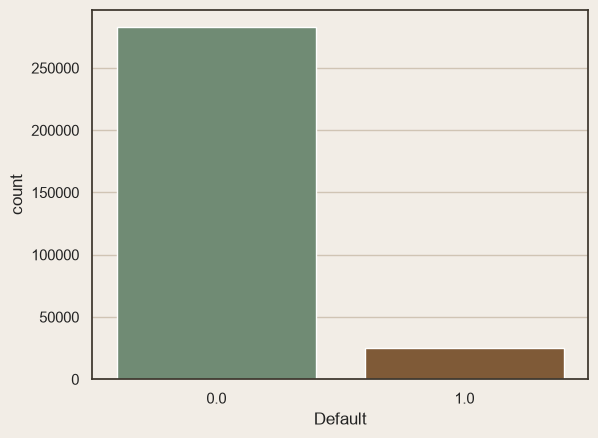

In [13]:
sns.countplot(x="Default", data=df, palette=[earth_palette[0], earth_palette[1]])
plt.show()

In [14]:
# # Pairplot (Quantitative Data) -- only a curated subset, 65 numeric columns is too many
# df["Default"] = df["Default"].map({0: "No", 1: "Yes"})
# sns.pairplot(df.loc[:, ['Income', 'Credit Amount', 'Annuity', 'Age', 'External Score 2', 'External Score 3', 'Default']], hue = 'Default')
# plt.show()

# df["Default"] = df["Default"].map({'No': 0, "Yes": 1})

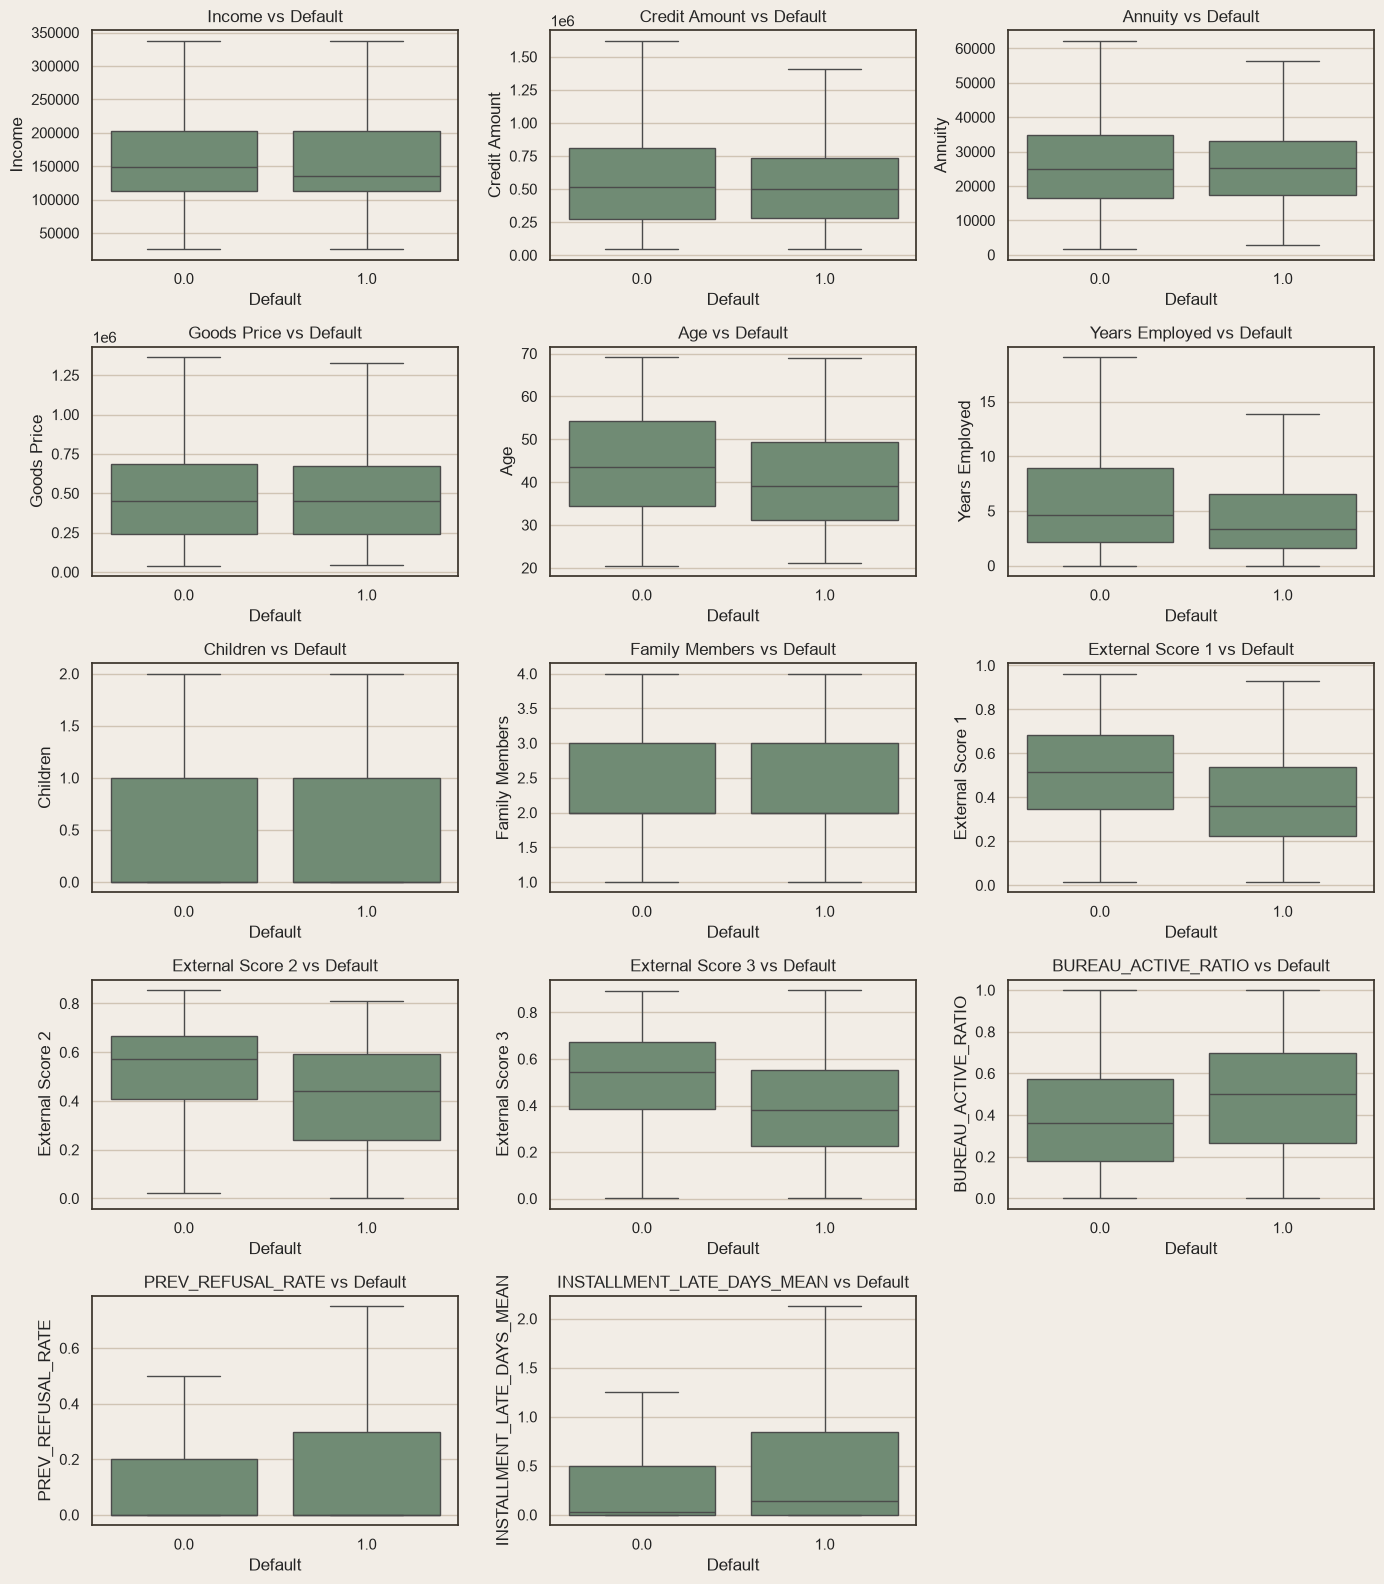

In [15]:
# Boxplots to visualize against target variable
# Curated subset of numeric predictors (full 65-column loop is unreadable / slow on 307k rows)
num_cols = [
    'Income', 'Credit Amount', 'Annuity', 'Goods Price',
    'Age', 'Years Employed', 'Children', 'Family Members',
    'External Score 1', 'External Score 2', 'External Score 3',
    'BUREAU_ACTIVE_RATIO', 'PREV_REFUSAL_RATE', 'INSTALLMENT_LATE_DAYS_MEAN',
]

plt.figure(figsize=(14, 16))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.boxplot(data=df, x="Default", y=col, showfliers=False)
    plt.title(f"{col} vs Default")
    plt.tight_layout()

plt.show()

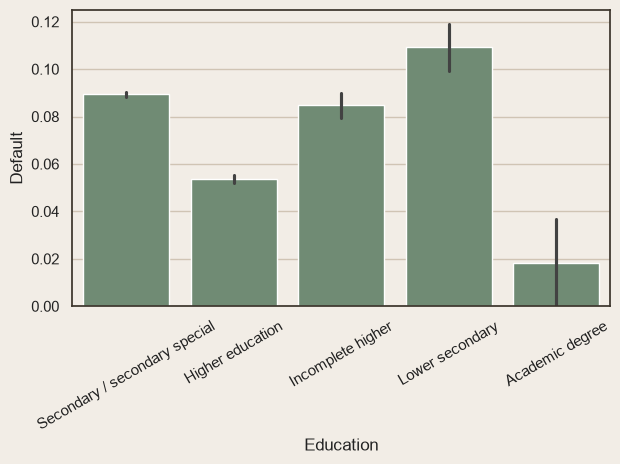

In [16]:
# Generate barplot of a variable with hue = resp var
sns.barplot(
    data=df,
    x="Education",
    y="Default",
)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Categorical Variable Checks

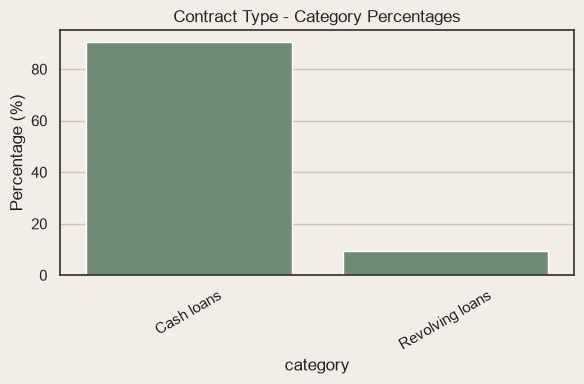

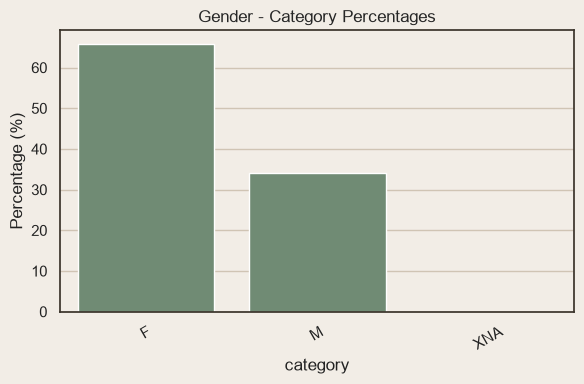

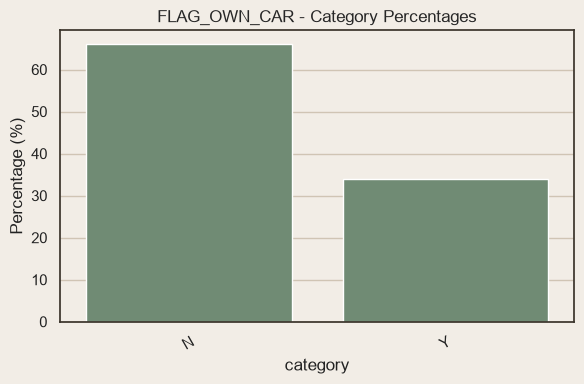

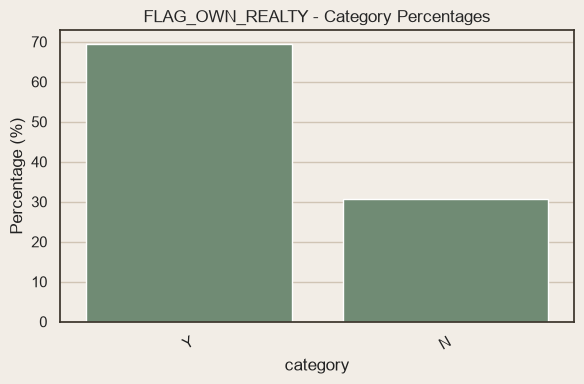

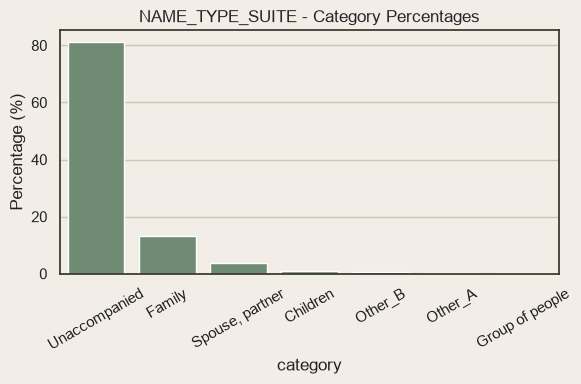

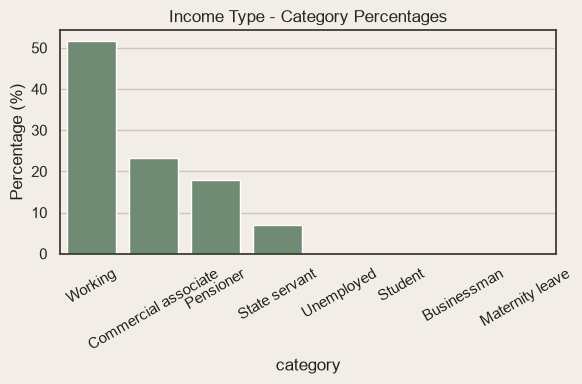

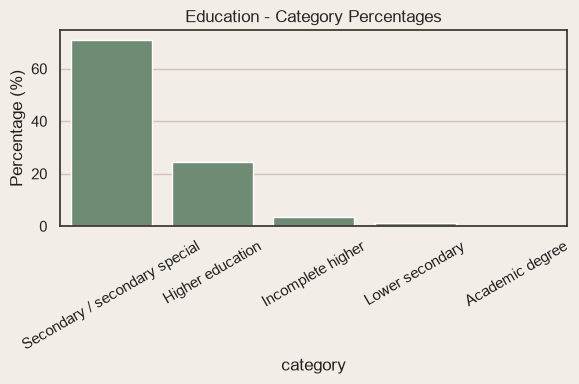

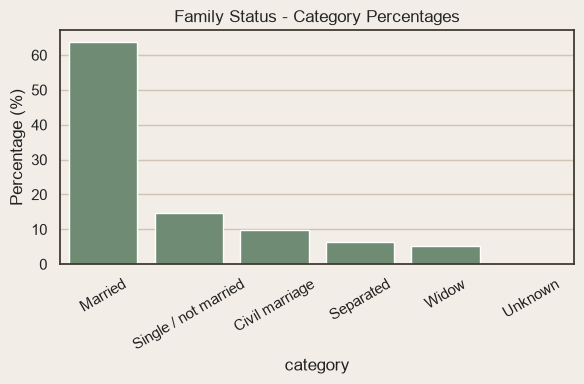

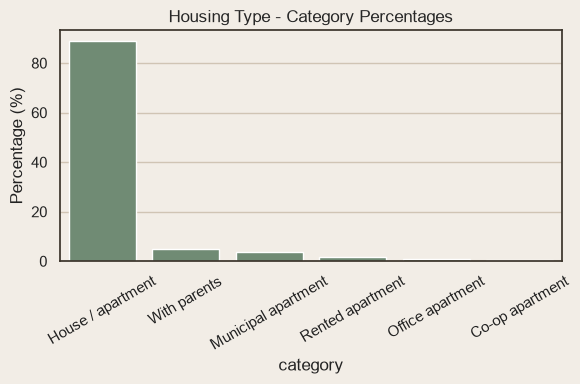

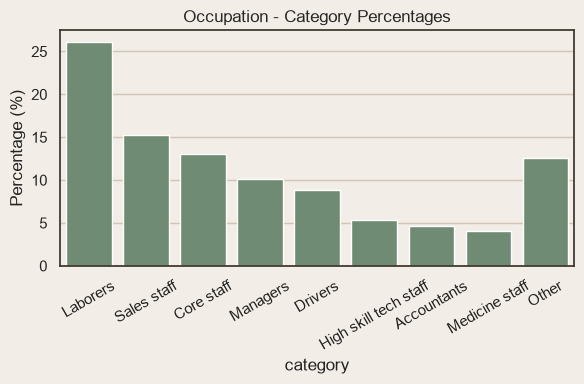

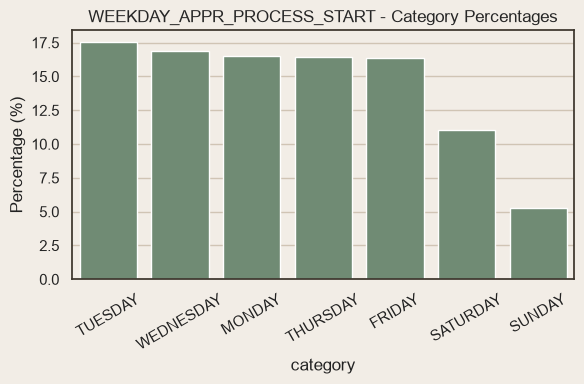

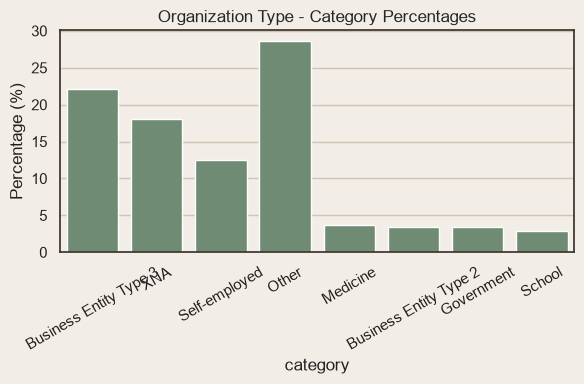

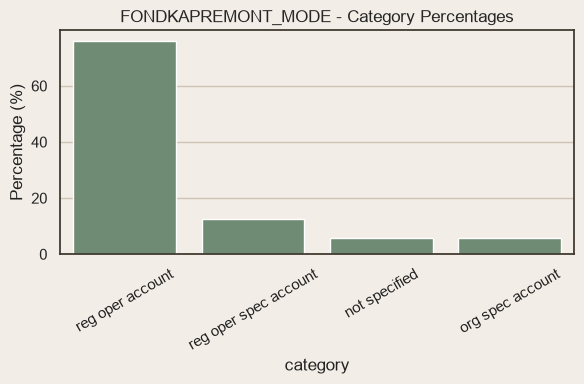

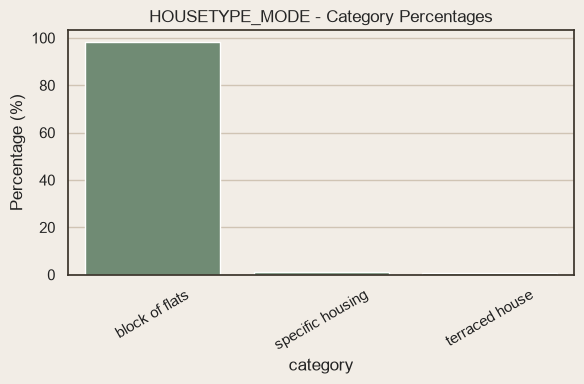

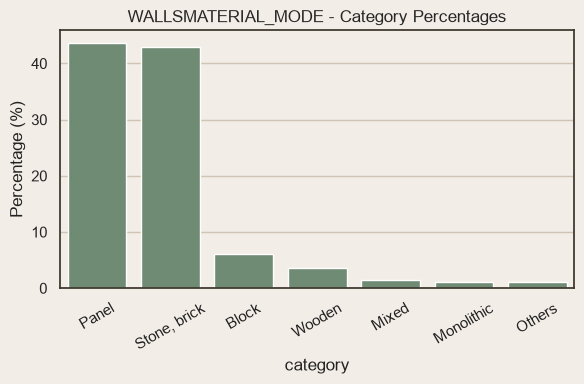

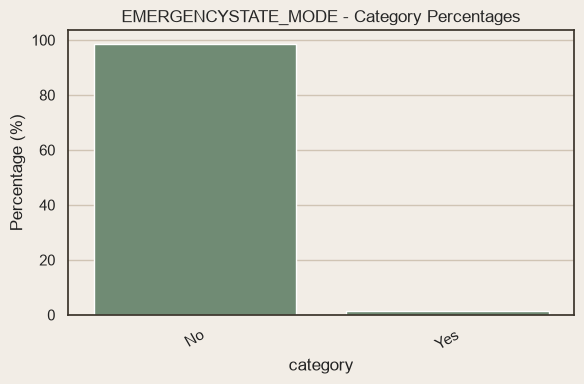

In [17]:
# Sanitize columns

def top_n_counts(series, n=25):
    counts = series.value_counts(normalize=True) * 100
    top = counts.iloc[:n].copy()
    other = counts.iloc[n:].sum()
    if other > 0:
        top['Other'] = other
    out = top.reset_index()
    out.columns = ['category', 'percent']  # fixed names
    return out

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6, 4))

    d = top_n_counts(df[col], n=8)

    # use the fixed column name 'category' here
    sns.barplot(data=d, x='category', y='percent')
    plt.title(f"{col} - Category Percentages")
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

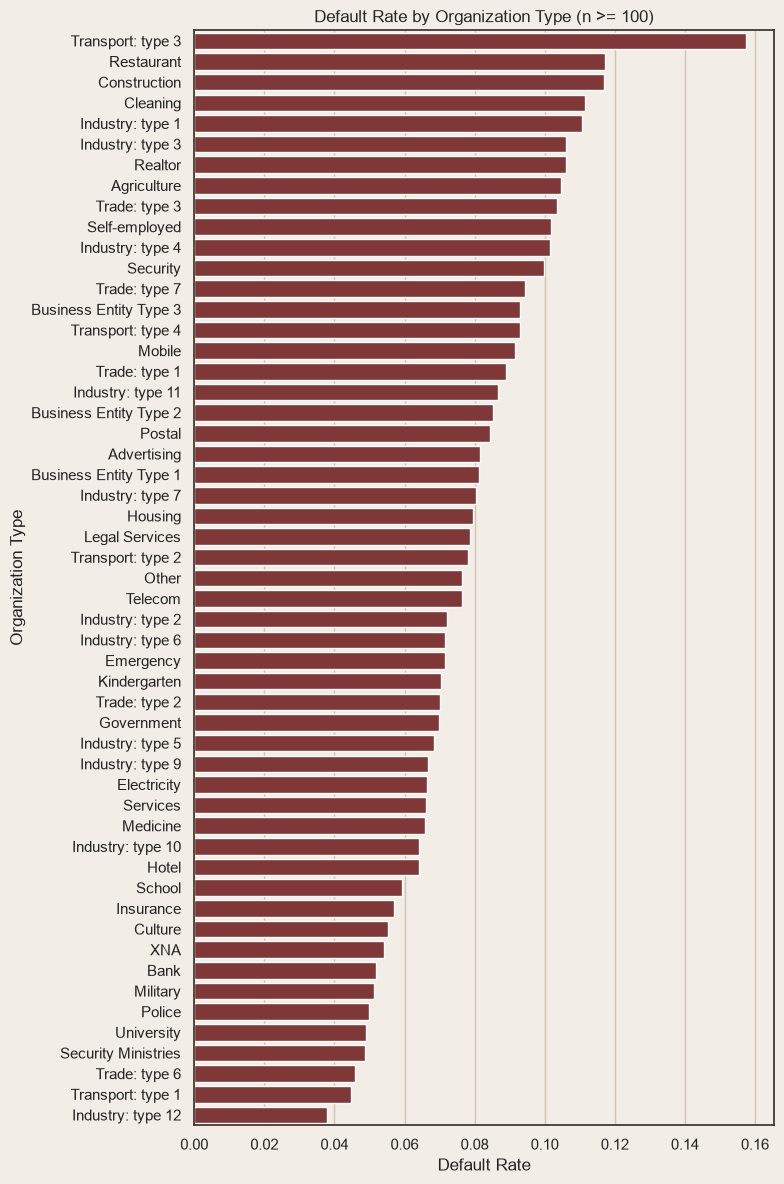

In [18]:
# LC_loans had a State column, so a choropleth made sense there.
# Home Credit has no geography -- Organization Type is the closest "where do they
# come from" categorical, so summarize default rate by group the same way.
org_summary = (
    df.groupby("Organization Type")
      .agg(
          default_rate=("Default", "mean"),
          default_count=("Default", "sum"),
          n_loans=("Default", "size"),
      )
      .query("n_loans >= 100")
      .sort_values("default_rate", ascending=False)
      .reset_index()
)

plt.figure(figsize=(8, 12))
sns.barplot(data=org_summary, y="Organization Type", x="default_rate", color=earth_palette[4])
plt.title("Default Rate by Organization Type (n >= 100)")
plt.xlabel("Default Rate")
plt.tight_layout()
plt.show()

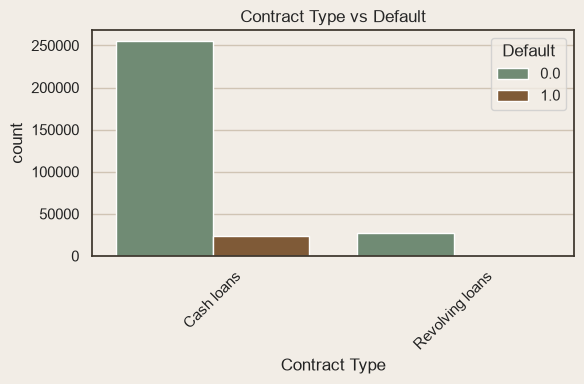

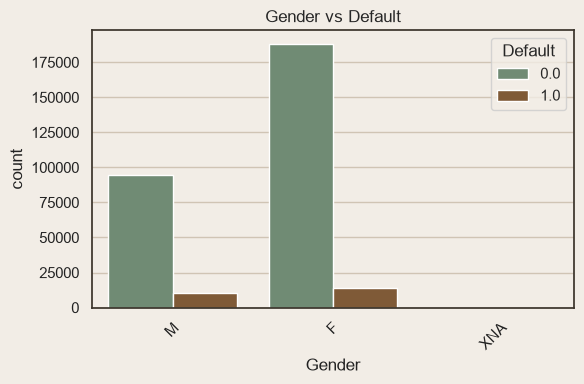

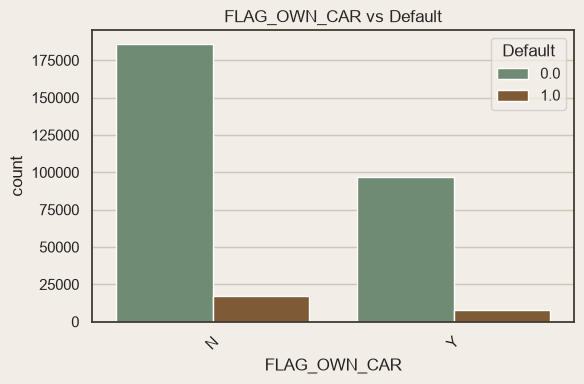

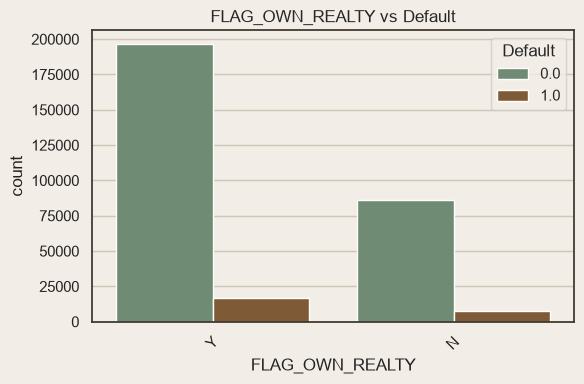

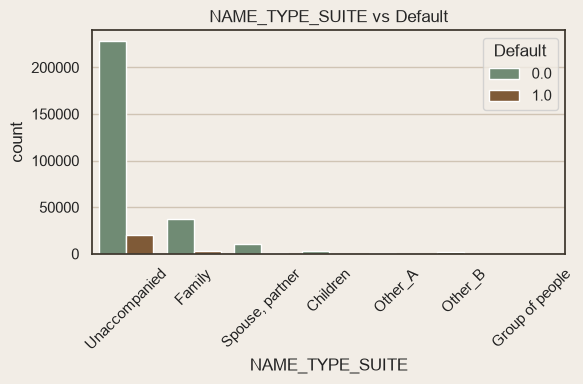

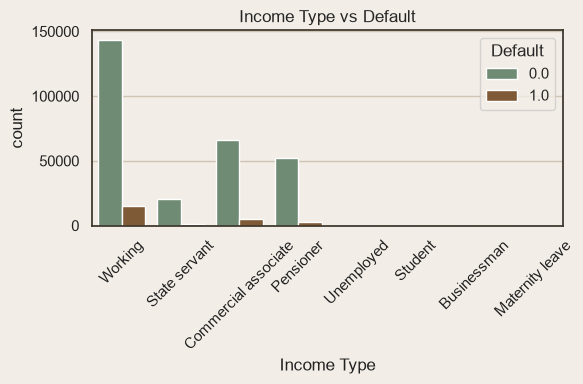

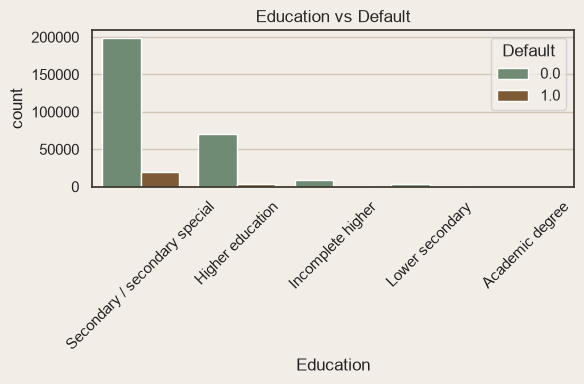

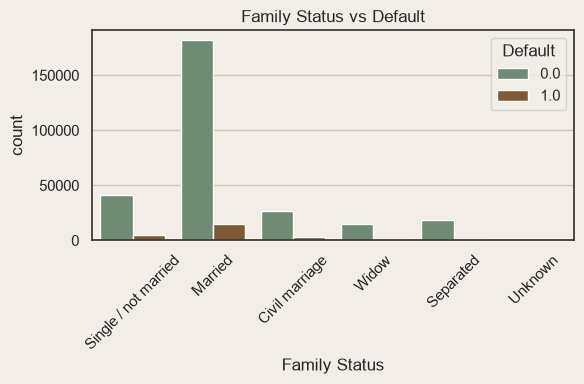

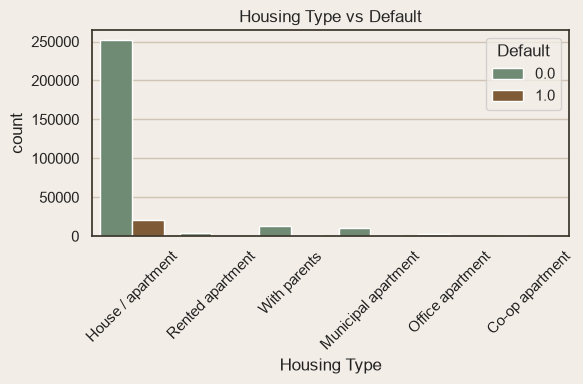

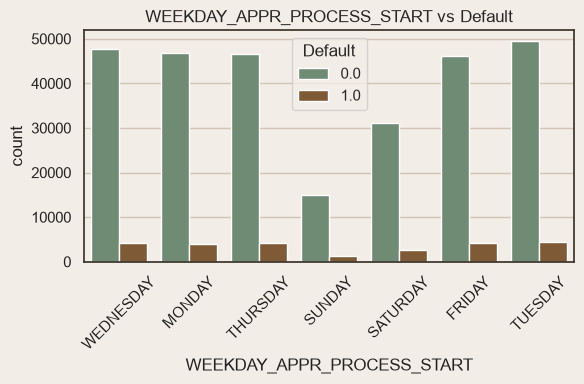

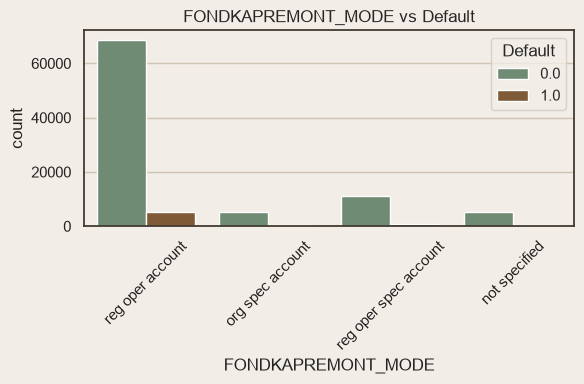

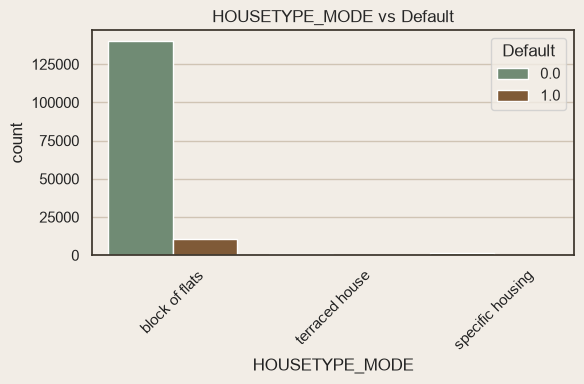

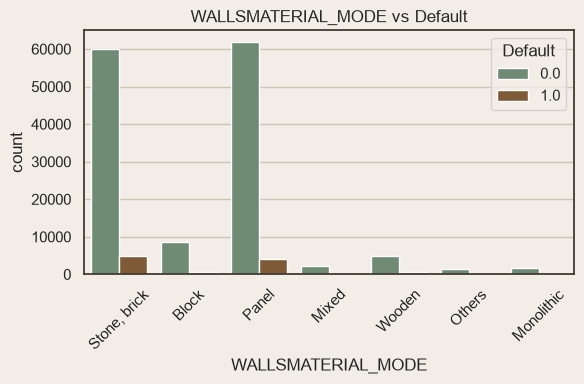

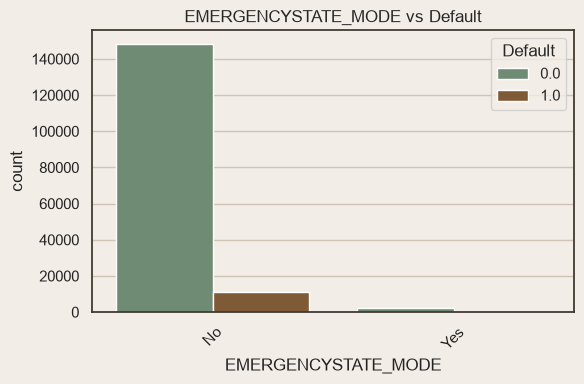

In [19]:
# Skip the very high-cardinality columns here, same reasoning as skipping
# State/Zipcode/Loan Purpose in the LC_loans version -- too wide to read as a countplot
high_cardinality = {'Organization Type', 'Occupation'}

for col in cat_cols:
    if col in high_cardinality:
        continue
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue="Default")
    plt.title(f"{col} vs Default")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [20]:
for col in cat_cols:
    print(col)

Contract Type
Gender
FLAG_OWN_CAR
FLAG_OWN_REALTY
NAME_TYPE_SUITE
Income Type
Education
Family Status
Housing Type
Occupation
WEEKDAY_APPR_PROCESS_START
Organization Type
FONDKAPREMONT_MODE
HOUSETYPE_MODE
WALLSMATERIAL_MODE
EMERGENCYSTATE_MODE


In [21]:
# Look at correlation matrix
corr_matrix = df.corr(numeric_only=True).round(2)
corr_matrix

,Default,Children,Income,Credit Amount,Annuity,Goods Price,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,CC_SK_DPD_MEAN,CC_DRAWINGS_ATM_MEAN,CC_CNT_DRAWINGS_MEAN,CC_PAYMENT_TO_MIN_MEAN,INSTALLMENT_COUNT,INSTALLMENT_LATE_DAYS_MEAN,INSTALLMENT_PAYMENT_DIFF_MEAN,INSTALLMENT_LATE_RATE,INSTALLMENT_UNDERPAID_RATE,INSTALLMENT_NUM_VERSION_NUNIQUE
Default,1.00,0.02,-0.00,-0.03,-0.01,-0.04,-0.04,0.08,0.07,0.04,...,-0.00,0.06,0.08,-0.0,-0.02,0.01,0.03,0.07,0.06,-0.00
Children,0.02,1.00,0.01,0.00,0.02,-0.00,-0.03,0.33,0.06,0.18,...,-0.01,0.00,0.04,0.0,-0.03,0.00,0.01,0.02,0.02,-0.01
Income,-0.00,0.01,1.00,0.16,0.19,0.16,0.07,0.03,-0.01,0.03,...,-0.01,0.05,0.03,0.0,0.02,-0.00,-0.02,0.00,-0.00,0.02
Credit Amount,-0.03,0.00,0.16,1.00,0.77,0.99,0.10,-0.06,-0.09,0.01,...,0.01,-0.02,-0.04,0.0,0.04,-0.00,-0.07,-0.04,-0.04,0.04
Annuity,-0.01,0.02,0.19,0.77,1.00,0.78,0.12,0.01,-0.05,0.04,...,0.00,-0.02,-0.02,0.0,0.02,-0.00,-0.05,-0.01,-0.00,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INSTALLMENT_LATE_DAYS_MEAN,0.01,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.01,-0.01,-0.00,...,0.28,-0.02,-0.02,0.0,0.00,1.00,0.03,0.20,0.18,-0.00
INSTALLMENT_PAYMENT_DIFF_MEAN,0.03,0.01,-0.02,-0.07,-0.05,-0.07,-0.01,0.04,0.02,0.01,...,0.01,-0.04,0.03,0.0,0.04,0.03,1.00,0.21,0.24,-0.38
INSTALLMENT_LATE_RATE,0.07,0.02,0.00,-0.04,-0.01,-0.04,0.00,0.02,0.01,0.00,...,0.05,0.01,-0.03,-0.0,0.08,0.20,0.21,1.00,0.81,-0.02
INSTALLMENT_UNDERPAID_RATE,0.06,0.02,-0.00,-0.04,-0.00,-0.04,0.01,0.03,0.02,0.01,...,0.03,0.04,-0.01,-0.0,0.08,0.18,0.24,0.81,1.00,-0.03


In [22]:
# Zooming in on the response variable
corr_matrix['Default'].sort_values(ascending=False)

Default                    1.00
CC_UTILIZATION_MEAN        0.14
BUREAU_DAYS_CREDIT_MEAN    0.09
CC_CNT_DRAWINGS_MEAN       0.08
DAYS_BIRTH                 0.08
                           ... 
Years Employed            -0.07
Age                       -0.08
External Score 1          -0.16
External Score 2          -0.16
External Score 3          -0.18
Name: Default, Length: 148, dtype: float64

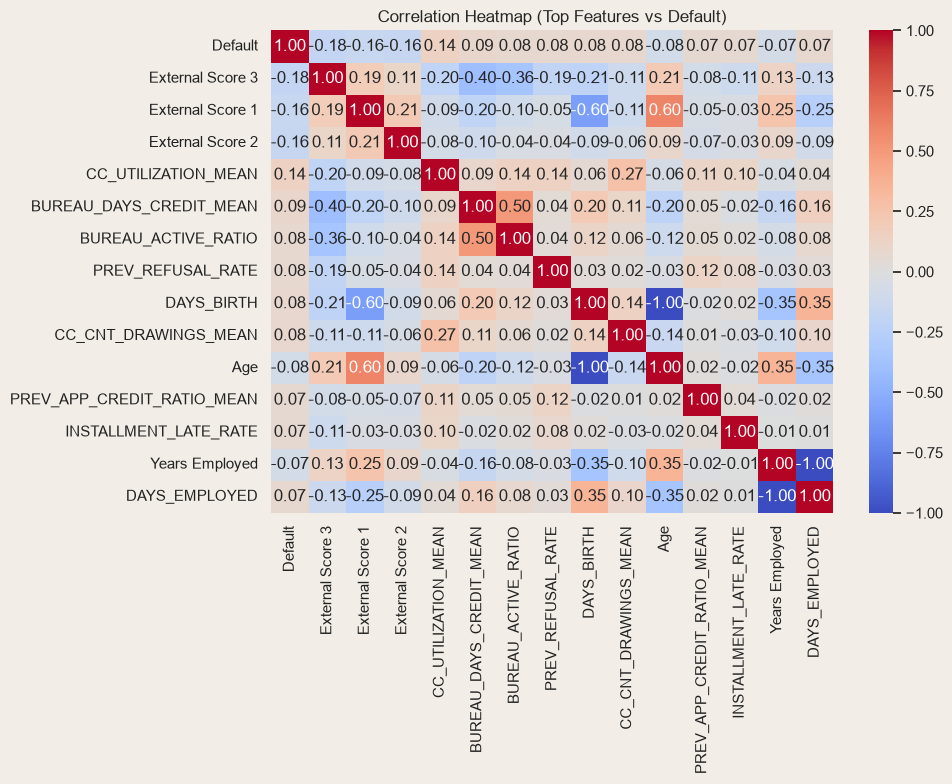

In [23]:
# Full 65-column heatmap is unreadable, so zoom in on the columns most correlated with Default
top_corr_cols = corr_matrix['Default'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_cols].corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Top Features vs Default)")
plt.tight_layout()
plt.show()

So far, it seems as though the three external credit bureau scores (External Score 1/2/3) are by far the most related features to defaulting, followed distantly by age and days-since-ID-published. No major multicollinearity is present between predictors that will impact a linear model, although it should be noted that the external scores are mildly correlated with each other (as expected, since they're all measuring similar underlying creditworthiness).

## Data Preprocessing

In [24]:
# Split predictors and response variable
X = df.drop(["Default"], axis=1)
y = df["Default"]

# Train-test split (before preprocessing!) using stratification to preserve class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
import numpy as np

num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(
    include=["object", "category", "bool", "string"]
).columns

print("Numeric:", list(num_cols))
print("Categorical:", list(cat_cols))

Numeric: ['Children', 'Income', 'Credit Amount', 'Annuity', 'Goods Price', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'Family Members', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'External Score 1', 'External Score 2', 'External Score 3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONA

In [26]:
# Preprocessing pipelines for numeric and categorical data, then combine them into a column transformer.
# Unlike LC_loans, Home Credit has heavy missingness, so both pipelines need an imputer first.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric + categorical transformers into one preprocessor
# Column transformer applies the appropriate transformations to each column subset and concatenates the results!
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

## Modeling: Cross validation for model selection

In [27]:
from imblearn.pipeline import Pipeline as ImbPipeline  # Pipeline optimized for imbalanced datasets
from sklearn.linear_model import LogisticRegression  # Base model
from xgboost import XGBClassifier  # Gradient-boosted ensemble model
from sklearn.neural_network import MLPClassifier  # Deep learning model

import mlflow  # Track experiments
import os

# MLflow 3.x requires a database backend now (file-based ./mlruns is deprecated).
# Its own default URI resolution percent-encodes spaces in the cwd (e.g. "Honors
# Research Project") but then uses that encoded string as a literal path when
# creating the db file, producing a bogus "%20"-named directory. Build the sqlite
# URI from the raw (unencoded) absolute path instead to avoid that.
mlflow.set_tracking_uri(f"sqlite:///{os.path.abspath('mlflow.db')}")
mlflow.set_experiment("home-credit-default-risk")

# Define pipelines for each model, including preprocessing and maybe SMOTE for oversampling the minority class
lr_clf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),   # imputer + scaler + onehot etc.
    # ("smote", SMOTE()),               # oversample minority class on processed features
    ("model", LogisticRegression(class_weight={0: 1.0, 1: 2.4}, max_iter=1000))
])

xgb_clf = ImbPipeline([
    ("preprocessor", preprocessor),
    # ("smote", SMOTE()),
    ("model", XGBClassifier(
        tree_method="auto",  # auto-select based on data size and hardware
        eval_metric="aucpr",  # Area Under the Precision-Recall Curve, good for imbalanced classification. Can't do this with logistic regression or mlp
        objective="binary:logistic",
    )),
])

nn_clf = ImbPipeline([
    ("preprocessor", preprocessor),
    # ("smote", SMOTE()),
    ("model", MLPClassifier(max_iter=400, solver="adam"))
])

/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
# Choose part of dataset to tune model with, full training dataset is not needed
from sklearn.model_selection import StratifiedShuffleSplit

target_size = 20000  # or even 50_000 if crashing still happens
test_size = len(X_train) - target_size
test_frac = test_size / len(X_train)

sss = StratifiedShuffleSplit(n_splits=1, test_size=test_frac, random_state=42)

for train_idx, _ in sss.split(X_train, y_train):
    X_tune = X_train.iloc[train_idx]
    y_tune = y_train.iloc[train_idx]

### CV: Logistic Regression

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    # "smote__k_neighbors": [3, 5, 7],
    "model__C": [0.1, 1, 10],  # Small -> more regularization, Large -> less regularization
    "model__penalty": ["l2"],   # Shrinks coefficients towards zero, but not exactly zero, so all features are kept in the model..uses l2 regularization
    "model__solver": ["lbfgs"]
}

grid_lr = GridSearchCV(
    estimator=lr_clf,
    param_grid=param_grid_lr,
    scoring="average_precision",
    cv=5,
    # n_jobs=2,          # or 2 for some parallelism
    # pre_dispatch=2     # or "2*n_jobs" (helps limit how many jobs are spawned)
)

grid_lr.fit(X_tune, y_tune)
print("Best LR params:", grid_lr.best_params_)
print("Best LR CV score:", grid_lr.best_score_)

/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


...

/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best LR params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best LR CV score: 0.22342497718107796


### CV: XGBoost

In [30]:
param_grid_xgb = {
    # "smote__k_neighbors": [3, 5],
    "model__max_depth": [2, 3, 5],
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.001, 0.02, 0.05],
    "model__scale_pos_weight": [3, 6, 11],  # or [1, ratio/2, ratio, 2*ratio], where ratio = num_negatives / num_positives
}

grid_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid_xgb,
    scoring="average_precision",
    cv=5,
    # n_jobs=2,
    # pre_dispatch=2
)

grid_xgb.fit(X_tune, y_tune)
print("Best XGB params:", grid_xgb.best_params_)
print("Best XGB CV score:", grid_xgb.best_score_)

Best XGB params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 400, 'model__scale_pos_weight': 3}
Best XGB CV score: 0.23658004948694605


### CV: XGBoost with Optuna

`GridSearchCV` above only searched 3-4 values per param on a fixed grid (54 combos).
XGBoost has more hyperparameters worth tuning (regularization, subsampling) than a grid
can cover without exploding combinatorially -- Optuna's TPE sampler searches a wider,
continuous space and spends its trial budget where it's actually paying off, instead of
wasting trials on combinations a grid would have to brute-force.

In [31]:
import optuna
from optuna.integration.mlflow import MLflowCallback
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }

    model = ImbPipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            tree_method="auto",
            eval_metric="aucpr",
            objective="binary:logistic",
            **params,
        )),
    ])

    scores = cross_val_score(model, X_tune, y_tune, scoring="average_precision", cv=5)
    return scores.mean()

mlflc = MLflowCallback(tracking_uri=mlflow.get_tracking_uri(), metric_name="avg_precision", create_experiment=False, mlflow_kwargs={"nested": True})

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
with mlflow.start_run(run_name="xgb_optuna_search"):
    study.optimize(objective, n_trials=40, show_progress_bar=True, callbacks=[mlflc])
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_cv_avg_precision", study.best_value)

print("Best Optuna XGB params:", study.best_params)
print("Best Optuna XGB CV score:", study.best_value)

/var/folders/db/t370rccd4wd43zxlc93bzwym0000gn/T/ipykernel_29397/3829684135.py:33: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflc = MLflowCallback(tracking_uri=mlflow.get_tracking_uri(), metric_name="avg_precision", create_experiment=False, mlflow_kwargs={"nested": True})



  0%|          | 0/40 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.231357:   0%|          | 0/40 [00:08<?, ?it/s]


Best trial: 0. Best value: 0.231357:   2%|▎         | 1/40 [00:08<05:44,  8.82s/it]


Best trial: 0. Best value: 0.231357:   2%|▎         | 1/40 [00:12<05:44,  8.82s/it]

...


Best trial: 20. Best value: 0.247739:  98%|█████████▊| 39/40 [04:00<00:05,  5.44s/it]


Best trial: 20. Best value: 0.247739:  98%|█████████▊| 39/40 [04:05<00:05,  5.44s/it]


Best trial: 20. Best value: 0.247739: 100%|██████████| 40/40 [04:05<00:00,  5.10s/it]


Best trial: 20. Best value: 0.247739: 100%|██████████| 40/40 [04:05<00:00,  6.13s/it]

Best Optuna XGB params: {'max_depth': 4, 'n_estimators': 293, 'learning_rate': 0.03283130170288954, 'scale_pos_weight': 3.7480682572931348, 'subsample': 0.7237093364189056, 'colsample_bytree': 0.7636004284281295, 'min_child_weight': 6, 'reg_alpha': 0.057439331639992375, 'reg_lambda': 9.44867998440012}
Best Optuna XGB CV score: 0.2477391313362837


In [32]:
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

### CV: LightGBM with Optuna

Leaf-wise tree growth instead of XGBoost's level-wise growth -- usually faster to train
and competitive or better accuracy on tabular data like this. Same Optuna setup as
XGBoost above, same `preprocessor`, same 20k-row tuning subsample, for an apples-to-apples
comparison.

In [33]:
from lightgbm import LGBMClassifier

def objective_lgbm(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 8, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 12),
    }

    model = ImbPipeline([
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            objective="binary",
            subsample_freq=1,  # LightGBM ignores `subsample` unless bagging is enabled with a freq
            verbosity=-1,
            **params,
        )),
    ])

    scores = cross_val_score(model, X_tune, y_tune, scoring="average_precision", cv=5)
    return scores.mean()

mlflc_lgbm = MLflowCallback(tracking_uri=mlflow.get_tracking_uri(), metric_name="avg_precision", create_experiment=False, mlflow_kwargs={"nested": True})

study_lgbm = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
with mlflow.start_run(run_name="lgbm_optuna_search"):
    study_lgbm.optimize(objective_lgbm, n_trials=40, show_progress_bar=True, callbacks=[mlflc_lgbm])
    mlflow.log_params(study_lgbm.best_params)
    mlflow.log_metric("best_cv_avg_precision", study_lgbm.best_value)

print("Best LightGBM params:", study_lgbm.best_params)
print("Best LightGBM CV score:", study_lgbm.best_value)

/var/folders/db/t370rccd4wd43zxlc93bzwym0000gn/T/ipykernel_29397/673770937.py:30: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflc_lgbm = MLflowCallback(tracking_uri=mlflow.get_tracking_uri(), metric_name="avg_precision", create_experiment=False, mlflow_kwargs={"nested": True})



  0%|          | 0/40 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.229245:   0%|          | 0/40 [00:21<?, ?it/s]


Best trial: 0. Best value: 0.229245:   2%|▎         | 1/40 [00:21<13:50, 21.29s/it]


Best trial: 1. Best value: 0.245701:   2%|▎         | 1/40 [00:28<13:50, 21.29s/it]

...


Best trial: 32. Best value: 0.251828:  98%|█████████▊| 39/40 [07:20<00:09,  9.66s/it]


Best trial: 32. Best value: 0.251828:  98%|█████████▊| 39/40 [07:35<00:09,  9.66s/it]


Best trial: 32. Best value: 0.251828: 100%|██████████| 40/40 [07:35<00:00, 11.53s/it]


Best trial: 32. Best value: 0.251828: 100%|██████████| 40/40 [07:35<00:00, 11.40s/it]

Best LightGBM params: {'num_leaves': 37, 'max_depth': 10, 'n_estimators': 362, 'learning_rate': 0.01158774243708483, 'min_child_samples': 52, 'subsample': 0.7000347085097536, 'colsample_bytree': 0.7390223118936016, 'reg_alpha': 0.4633992503362058, 'reg_lambda': 0.036337126717267146, 'scale_pos_weight': 3.9518352551878237}
Best LightGBM CV score: 0.2518277946134412


### CV: CatBoost with Optuna

CatBoost's headline feature is native categorical handling (no one-hot needed) plus
ordered boosting to fight target leakage/overfitting -- but to keep this comparison
apples-to-apples with the other models, it still goes through the same `preprocessor`
(one-hot encoded) rather than being given the raw categorical columns directly.

In [34]:
from catboost import CatBoostClassifier

def objective_catboost(trial):
    params = {
        "depth": trial.suggest_int("depth", 3, 10),
        "iterations": trial.suggest_int("iterations", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "rsm": trial.suggest_float("rsm", 0.6, 1.0),  # colsample_bylevel equivalent
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 12),
    }

    model = ImbPipeline([
        ("preprocessor", preprocessor),
        ("model", CatBoostClassifier(
            bootstrap_type="Bernoulli",  # required for `subsample` to be a valid param
            verbose=False,
            allow_writing_files=False,  # skip writing a catboost_info/ dir to disk
            **params,
        )),
    ])

    scores = cross_val_score(model, X_tune, y_tune, scoring="average_precision", cv=5)
    return scores.mean()

mlflc_catboost = MLflowCallback(tracking_uri=mlflow.get_tracking_uri(), metric_name="avg_precision", create_experiment=False, mlflow_kwargs={"nested": True})

study_catboost = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
with mlflow.start_run(run_name="catboost_optuna_search"):
    study_catboost.optimize(objective_catboost, n_trials=40, show_progress_bar=True, callbacks=[mlflc_catboost])
    mlflow.log_params(study_catboost.best_params)
    mlflow.log_metric("best_cv_avg_precision", study_catboost.best_value)

print("Best CatBoost params:", study_catboost.best_params)
print("Best CatBoost CV score:", study_catboost.best_value)

/var/folders/db/t370rccd4wd43zxlc93bzwym0000gn/T/ipykernel_29397/3710600995.py:27: FutureWarning: MLflowCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  mlflc_catboost = MLflowCallback(tracking_uri=mlflow.get_tracking_uri(), metric_name="avg_precision", create_experiment=False, mlflow_kwargs={"nested": True})



  0%|          | 0/40 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.22551:   0%|          | 0/40 [00:13<?, ?it/s]


Best trial: 0. Best value: 0.22551:   2%|▎         | 1/40 [00:13<08:38, 13.31s/it]


Best trial: 0. Best value: 0.22551:   2%|▎         | 1/40 [01:03<08:38, 13.31s/it]

...


Best trial: 13. Best value: 0.241935:  98%|█████████▊| 39/40 [15:44<00:19, 19.90s/it]


Best trial: 13. Best value: 0.241935:  98%|█████████▊| 39/40 [15:54<00:19, 19.90s/it]


Best trial: 13. Best value: 0.241935: 100%|██████████| 40/40 [15:54<00:00, 16.99s/it]


Best trial: 13. Best value: 0.241935: 100%|██████████| 40/40 [15:54<00:00, 23.86s/it]

Best CatBoost params: {'depth': 7, 'iterations': 486, 'learning_rate': 0.025556152459754355, 'l2_leaf_reg': 1.9332114161583103, 'subsample': 0.8505374744476087, 'rsm': 0.7696954281685016, 'scale_pos_weight': 4.77079217092948}
Best CatBoost CV score: 0.24193468853582684


### CV: Multi-layer Perceptron (Neural Network)

This can be done in sklearn or in pytorch. It may be more worthwhile to switch to pytorch.

In [35]:
from sklearn.model_selection import RandomizedSearchCV
param_grid_nn = {
    "model__hidden_layer_sizes": [(64,), (64, 64)],  # Tests one vs two hidden layers (same number of neurons)
    "model__alpha": [1e-4, 1e-3],
}

grid_nn = GridSearchCV(
    estimator=nn_clf,
    param_grid=param_grid_nn,
    scoring="average_precision",
    cv=3,
    n_jobs=2,
    pre_dispatch=2
)

grid_nn.fit(X_tune, y_tune)
print("Best NN params:", grid_nn.best_params_)
print("Best NN CV score:", grid_nn.best_score_)

Best NN params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (64,)}
Best NN CV score: 0.14978566900962287


### Test Evaluation

In [36]:
from sklearn.metrics import roc_auc_score, classification_report, average_precision_score

best_lr = grid_lr.best_estimator_
best_xgb = grid_xgb.best_estimator_
best_nn = grid_nn.best_estimator_

best_xgb_optuna = ImbPipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        tree_method="auto",
        eval_metric="aucpr",
        objective="binary:logistic",
        **study.best_params,
    )),
])

best_lgbm_optuna = ImbPipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        objective="binary",
        subsample_freq=1,
        verbosity=-1,
        **study_lgbm.best_params,
    )),
])

best_catboost_optuna = ImbPipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        bootstrap_type="Bernoulli",
        verbose=False,
        allow_writing_files=False,
        **study_catboost.best_params,
    )),
])

models = {
    "logistic_regression": best_lr,
    "xgboost_gridsearch": best_xgb,
    "xgboost_optuna": best_xgb_optuna,
    "lightgbm_optuna": best_lgbm_optuna,
    "catboost_optuna": best_catboost_optuna,
    "neural_net": best_nn,
}

results = {}

# Refit on full train and evaluate on test
for name, model in models.items():
    with mlflow.start_run(run_name=f"test_eval_{name}"):
        # refit tuned pipeline on full training data
        model.fit(X_train, y_train)

        # predictions on test
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_proba)
        ap = average_precision_score(y_test, y_proba)
        results[name] = {"auc": auc, "ap": ap}

        model_params = model.named_steps["model"].get_params()
        loggable_params = {k: v for k, v in model_params.items() if isinstance(v, (int, float, str, bool)) or v is None}
        mlflow.log_params(loggable_params)
        mlflow.log_metric("test_auc", auc)
        mlflow.log_metric("test_avg_precision", ap)

        print(f"\n===== {name} =====")
        print("Classification report:")
        print(classification_report(y_test, y_pred))
        print(f"Test AUC: {auc:.3f}")
        print(f"Test Average Precision: {ap:.3f}")

# Pick the actual best model by test average precision -- SHAP + threshold tuning below use this
best_model_name = max(results, key=lambda name: results[name]["ap"])
print(f"\nBest model by test Average Precision: {best_model_name} (AP={results[best_model_name]['ap']:.3f}, AUC={results[best_model_name]['auc']:.3f})")

/opt/miniconda3/envs/honorsproject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(



===== logistic_regression =====
Classification report:
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95     56538
         1.0       0.38      0.15      0.22      4965

    accuracy                           0.91     61503
   macro avg       0.65      0.56      0.58     61503
weighted avg       0.88      0.91      0.89     61503

Test AUC: 0.767
Test Average Precision: 0.252



===== xgboost_gridsearch =====
Classification report:
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95     56538
         1.0       0.39      0.18      0.24      4965

    accuracy                           0.91     61503
   macro avg       0.66      0.58      0.60     61503
weighted avg       0.89      0.91      0.90     61503

Test AUC: 0.772
Test Average Precision: 0.264



===== xgboost_optuna =====
Classification report:
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.95     56538
         1.0       0.34      0.27      0.30      4965

    accuracy                           0.90     61503
   macro avg       0.64      0.61      0.62     61503
weighted avg       0.89      0.90      0.89     61503

Test AUC: 0.776
Test Average Precision: 0.272



===== lightgbm_optuna =====
Classification report:
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.94     56538
         1.0       0.33      0.27      0.30      4965

    accuracy                           0.90     61503
   macro avg       0.64      0.61      0.62     61503
weighted avg       0.89      0.90      0.89     61503

Test AUC: 0.776
Test Average Precision: 0.272



===== catboost_optuna =====
Classification report:
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93     56538
         1.0       0.30      0.36      0.33      4965

    accuracy                           0.88     61503
   macro avg       0.62      0.64      0.63     61503
weighted avg       0.89      0.88      0.89     61503

Test AUC: 0.779
Test Average Precision: 0.275



===== neural_net =====
Classification report:
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95     56538
         1.0       0.33      0.12      0.18      4965

    accuracy                           0.91     61503
   macro avg       0.63      0.55      0.56     61503
weighted avg       0.88      0.91      0.89     61503

Test AUC: 0.734
Test Average Precision: 0.211

Best model by test Average Precision: catboost_optuna (AP=0.275, AUC=0.779)


## Model Explainability: SHAP

Explain the best model by test Average Precision (`best_model_name`, picked in the cell
above) with SHAP so the feature importances aren't just a black box. `TreeExplainer` is
exact and fast for tree ensembles (works for XGBoost, LightGBM, and CatBoost alike), so
no need to subsample rows for speed, but we subsample anyway to keep the summary plot
legible.

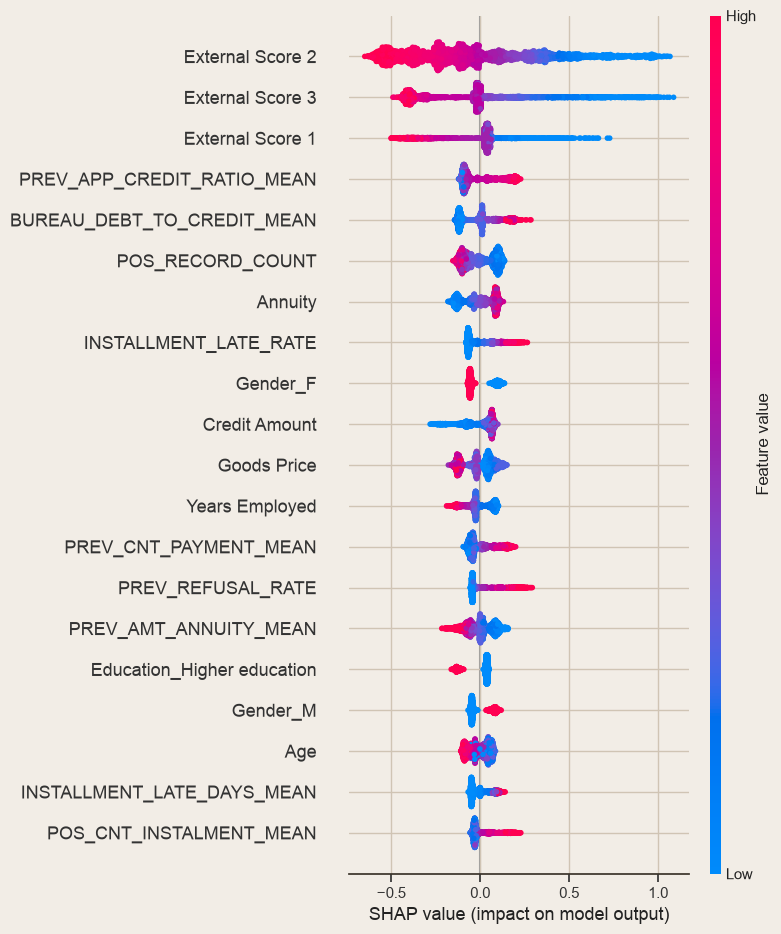

In [37]:
import shap

best_model = models[best_model_name]  # already fit on X_train in the test-eval loop above
tree_model = best_model.named_steps["model"]
preprocessor_fitted = best_model.named_steps["preprocessor"]
feature_names = [c.split("__", 1)[-1] for c in preprocessor_fitted.get_feature_names_out()]

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_test), size=3000, replace=False)
X_sample = preprocessor_fitted.transform(X_test.iloc[sample_idx])
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_sample)
# Binary classifiers sometimes return a list of per-class arrays -- keep the positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

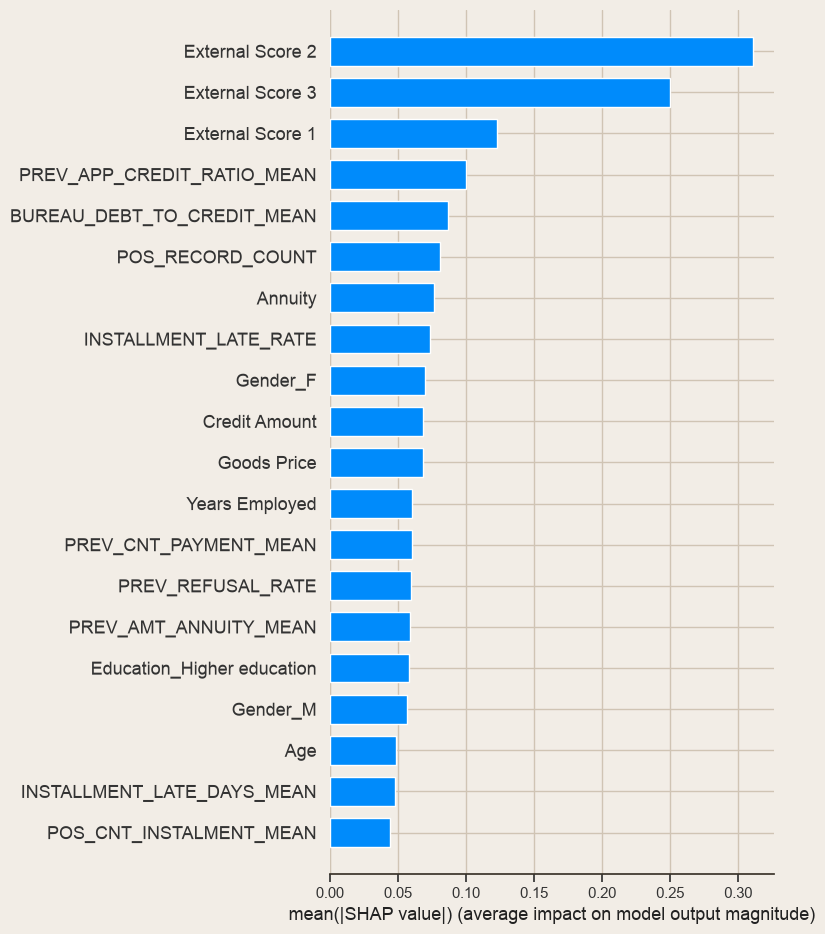

In [38]:
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

## Probability Calibration

A quick manual sanity-check of the deployed API on synthetic loan applications turned
up something worth stopping for: even deliberately "risky" profiles (unemployed, big
loan relative to income, maxed-out credit card) stayed well under the 46.3% decision
threshold, and only a profile with *every* risk factor stacked at once got flagged.
That's suspicious given `catboost_optuna`'s CV/test AUC and AP both looked solid --
worth checking whether `predict_proba()` actually means what it claims to mean.

In [ ]:
proba_uncalibrated = models["catboost_optuna"].predict_proba(X_test)[:, 1]

print("=== Raw probability distribution on the real held-out test set ===")
print(f"True base rate (actual default %):     {y_test.mean():.1%}")
print(f"Mean predicted probability:              {proba_uncalibrated.mean():.1%}")
print(f"Median predicted probability:             {np.median(proba_uncalibrated):.1%}")
print(f"90th percentile predicted probability:    {np.percentile(proba_uncalibrated, 90):.1%}")
print(f"99th percentile predicted probability:    {np.percentile(proba_uncalibrated, 99):.1%}")

df_cal = pd.DataFrame({"proba": proba_uncalibrated, "actual": y_test.values})
df_cal["decile"] = pd.qcut(df_cal["proba"], 10, labels=False, duplicates="drop")
print()
print(df_cal.groupby("decile").agg(mean_predicted=("proba", "mean"), actual_default_rate=("actual", "mean"), n=("actual", "size")).reset_index().to_string(index=False))

=== Raw probability distribution on the real held-out test set ===
True base rate (actual default %):     8.1%
Mean predicted probability:              25.0%
Median predicted probability:             20.5%
90th percentile predicted probability:    49.5%
99th percentile predicted probability:    74.0%

 decile  mean_predicted  actual_default_rate    n
      0        0.058268             0.010242 6151
      1        0.092745             0.020000 6150
      2        0.121782             0.023089 6150
      3        0.152191             0.027805 6150
      4        0.186487             0.045684 6151
      5        0.226805             0.053171 6150
      6        0.276693             0.072358 6150
      7        0.342481             0.107154 6150
      8        0.435113             0.153171 6150
      9        0.609548             0.294586 6151


The mean predicted probability (25.0%) is roughly **3x** the true base rate (8.1%) --
and it's not just a constant offset, the whole scale is stretched: even the top decile
(mean predicted 61%) only actually defaults 29.5% of the time. The ranking itself is
fine (each decile's actual default rate increases monotonically), which is exactly what
AUC/AP measure and why those looked healthy -- but the *magnitude* of `predict_proba()`
doesn't mean "probability of default" in any literal sense.

This is a known side effect of `scale_pos_weight`: reweighting the training loss to
compensate for the 8.8% base rate is great for ranking (which is all `average_precision`
scoring ever asked it to do), but it systematically distorts the raw probability scale.
Fix: wrap the tuned model in `CalibratedClassifierCV` (isotonic regression) so
`predict_proba()` gets remapped to match observed frequencies, without touching the
underlying ranking the model already learned.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_catboost = CalibratedClassifierCV(
    ImbPipeline([
        ("preprocessor", preprocessor),
        ("model", CatBoostClassifier(
            bootstrap_type="Bernoulli", verbose=False, allow_writing_files=False,
            **study_catboost.best_params,
        )),
    ]),
    method="isotonic", cv=5,  # internal 5-fold CV -- calibrates on folds the base model never trained on
)
calibrated_catboost.fit(X_train, y_train)

proba_calibrated = calibrated_catboost.predict_proba(X_test)[:, 1]

print("=== BEFORE vs AFTER calibration (same held-out test set) ===")
print(f"True base rate:                {y_test.mean():.1%}")
print(f"Mean predicted (uncalibrated): {proba_uncalibrated.mean():.1%}")
print(f"Mean predicted (calibrated):   {proba_calibrated.mean():.1%}")
print(f"AUC uncalibrated: {roc_auc_score(y_test, proba_uncalibrated):.4f}   AUC calibrated: {roc_auc_score(y_test, proba_calibrated):.4f}")
print(f"AP  uncalibrated: {average_precision_score(y_test, proba_uncalibrated):.4f}   AP  calibrated: {average_precision_score(y_test, proba_calibrated):.4f}")

df_cal2 = pd.DataFrame({"proba": proba_calibrated, "actual": y_test.values})
df_cal2["decile"] = pd.qcut(df_cal2["proba"], 10, labels=False, duplicates="drop")
print()
print(df_cal2.groupby("decile").agg(mean_predicted=("proba", "mean"), actual_default_rate=("actual", "mean"), n=("actual", "size")).reset_index().to_string(index=False))

=== BEFORE vs AFTER calibration (same held-out test set) ===
True base rate:                8.1%
Mean predicted (uncalibrated): 25.0%
Mean predicted (calibrated):   8.0%
AUC uncalibrated: 0.7786   AUC calibrated: 0.7783
AP  uncalibrated: 0.2746   AP  calibrated: 0.2733

 decile  mean_predicted  actual_default_rate    n
      0        0.010218             0.010566 6152
      1        0.016776             0.018516 6157
      2        0.024106             0.022262 6199
      3        0.031446             0.031058 6182
      4        0.042639             0.044375 6062
      5        0.056129             0.055772 6150
      6        0.077089             0.069873 6154
      7        0.105946             0.110804 6146
      8        0.152534             0.148172 6155
      9        0.287128             0.296290 6146


In [ ]:
precisions_c, recalls_c, thresholds_c = precision_recall_curve(y_test, proba_calibrated)
f1_scores_c = 2 * precisions_c * recalls_c / (precisions_c + recalls_c + 1e-12)
best_idx_c = f1_scores_c[:-1].argmax()
calibrated_threshold = float(thresholds_c[best_idx_c])

print(f"New F1-optimal threshold (calibrated): {calibrated_threshold:.4f} (F1={f1_scores_c[best_idx_c]:.3f})")
print()
y_pred_c = (proba_calibrated >= calibrated_threshold).astype(int)
print(classification_report(y_test, y_pred_c))

New F1-optimal threshold (calibrated): 0.1647 (F1=0.332)

              precision    recall  f1-score   support

         0.0       0.95      0.90      0.92     56538
         1.0       0.27      0.43      0.33      4965

    accuracy                           0.86     61503
   macro avg       0.61      0.66      0.63     61503
weighted avg       0.89      0.86      0.87     61503



Calibration worked exactly as intended: mean predicted probability now matches the
true base rate almost exactly (8.0% vs 8.1%), and the decile table lines up predicted
against actual nearly 1:1 across the board. AUC and AP are essentially unchanged
(0.7786->0.7783, 0.2746->0.2733) -- expected, since isotonic regression is a monotonic
transform and can't change rank order, only rescale it. Classification performance at
the new F1-optimal threshold (0.165 instead of 0.463) is also basically identical
(F1 0.33 either way).

In other words: this was a pure interpretability fix, not a performance tradeoff. The
uncalibrated model was never "wrong" about *who* is riskier than whom -- it was wrong
about what number to put on it. `catboost_optuna_calibrated` (not `catboost_optuna`) is
what the API now serves, with the recalibrated threshold read from a saved JSON file
alongside the model.

## Threshold Tuning

AUC and Average Precision are threshold-independent, but the classification reports
above all used the default 0.5 cutoff -- arbitrary given an 8.78% base rate. Look at
the actual precision/recall/F1 tradeoff across thresholds for the best model
(`best_model_name`) before assuming 0.5 is the right cutoff to deploy with.

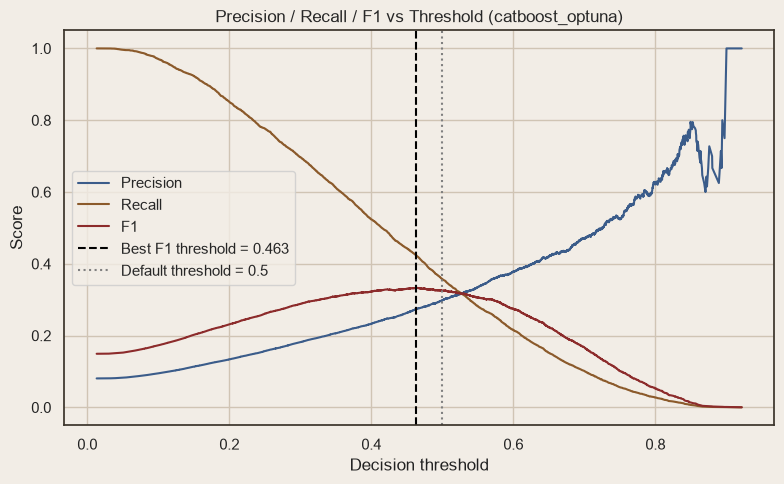

Best F1 threshold: 0.463 (F1 = 0.333)


In [39]:
from sklearn.metrics import precision_recall_curve

y_proba_best = models[best_model_name].predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color=earth_palette[2])
plt.plot(thresholds, recalls[:-1], label="Recall", color=earth_palette[1])
plt.plot(thresholds, f1_scores[:-1], label="F1", color=earth_palette[4])
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Best F1 threshold = {best_threshold:.3f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold = 0.5")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall / F1 vs Threshold ({best_model_name})")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {best_threshold:.3f} (F1 = {f1_scores[best_idx]:.3f})")

In [40]:
from sklearn.metrics import classification_report

y_pred_default = (y_proba_best >= 0.5).astype(int)
y_pred_tuned = (y_proba_best >= best_threshold).astype(int)

print("===== Default threshold (0.5) =====")
print(classification_report(y_test, y_pred_default))

print(f"===== Tuned threshold ({best_threshold:.3f}) =====")
print(classification_report(y_test, y_pred_tuned))

===== Default threshold (0.5) =====
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93     56538
         1.0       0.30      0.36      0.33      4965

    accuracy                           0.88     61503
   macro avg       0.62      0.64      0.63     61503
weighted avg       0.89      0.88      0.89     61503

===== Tuned threshold (0.463) =====
              precision    recall  f1-score   support

         0.0       0.95      0.90      0.92     56538
         1.0       0.27      0.42      0.33      4965

    accuracy                           0.86     61503
   macro avg       0.61      0.66      0.63     61503
weighted avg       0.89      0.86      0.88     61503



## Save Model Weights

Each entry in `models` is a full fitted `ImbPipeline` (preprocessing + trained model),
already refit on the complete training set in the test-eval loop above -- save the
whole pipeline with `joblib` so loading it back later doesn't require rebuilding the
`ColumnTransformer` by hand.

In [ ]:
import joblib
import json
import os

os.makedirs("models", exist_ok=True)
for name, model in models.items():
    path = f"models/{name}.joblib"
    joblib.dump(model, path)
    size_mb = os.path.getsize(path) / 1e6
    print(f"saved {path} ({size_mb:.1f} MB)")

# Calibrated model + its own tuned threshold (see "Probability Calibration" above) --
# this, not the raw catboost_optuna, is what api/main.py serves by default.
joblib.dump(calibrated_catboost, "models/catboost_optuna_calibrated.joblib")
with open("models/catboost_optuna_calibrated_threshold.json", "w") as f:
    json.dump({"threshold": calibrated_threshold}, f)
print("saved models/catboost_optuna_calibrated.joblib + threshold json")

<!-- PART2-START -->

---

# Part 2: Finding what actually improved it

Part 1 got to 0.7786 with CatBoost. The question here is what was holding it back: was it
the choice of model, or was the pipeline doing something wrong?

It was mostly the pipeline. Rebuilding it got test AUC to 0.7976, and two changes account
for 88% of the gain. One of them was a bug. Hyperparameter search, cohort features and
ensembling added 0.0017 between them.

**What the numbers mean.** Every score here is AUC. Take one applicant who defaulted and
one who did not, at random: AUC is the chance the model scores the defaulter as the riskier
of the two. 0.5 is a coin flip, 1.0 is perfect, and real credit models sit between 0.70 and
0.80. So the move from 0.7786 to 0.7976 looks small written down and is meaningful here.

**How each change was tested.** One change at a time, everything else held fixed, so the
difference in score belongs to that change and not to a bundle of them. The code calls this
an ablation.

Running all of this took about ten hours, which is too long for a notebook, so the cells
below load its saved output instead of recomputing it. The scripts that ran the
experiments have since been deleted; what remains is the numbers they produced.

Four files in `utilities/` are still in use: `build_features.py` builds the features, `evaluation.py` fixes
the train/test split and the cross-validation, `extra_features.py` adds the cohort
comparisons, and `run_one.py` runs one configuration through that setup.

| file in `utilities/results/` | what it holds |
|---|---|
| `ablation.json` | every configuration tried, with its cross-validation and test score |
| `blend_existing.json` | the final blend and the weight given to each model |
| `importances.csv` | features ranked by how much the model leaned on them |
| `final_metrics.json` | Gini, KS, calibration and gains for the deployed model |

## 2.1 How models were compared

Part 1 picked models by their test-set score. That defeats the point of holding data back,
and on this test set it is not even a precise measurement. There are 61,502 rows with
about 4,960 defaults, which puts the standard error of a single test AUC at 0.0039. Two
models within roughly 0.008 of each other on the test set cannot be told apart.

So every decision below is made on 5-fold cross-validation inside the 80% training split:
train on four fifths, score the fifth that was held out, repeat five times, average the
five scores. The test set gets read once per configuration, only to report.

This changed a real decision. In §2.7 the runner-up hyperparameter setting scored higher
on test than the one chosen, and was passed over anyway because it lost on
cross-validation.

In [ ]:
import json, os
import numpy as np, pandas as pd

UTILS = "utilities/results"

with open(f"{UTILS}/ablation.json") as f:
    RES = json.load(f)

def auc_se(n_pos, n_neg, auc):
    """Hanley-McNeil standard error of an AUC estimate."""
    q1, q2 = auc / (2 - auc), 2 * auc**2 / (1 + auc)
    var = (auc * (1 - auc) + (n_pos - 1) * (q1 - auc**2) + (n_neg - 1) * (q2 - auc**2)) / (n_pos * n_neg)
    return float(np.sqrt(var))

n_pos, n_neg = 4965, 56538
print(f"test set: {n_pos + n_neg:,} rows, {n_pos:,} positives ({n_pos/(n_pos+n_neg):.2%} base rate)")
print(f"AUC standard error at 0.797: +/- {auc_se(n_pos, n_neg, 0.797):.4f}")
print(f"=> test differences below ~{2*auc_se(n_pos, n_neg, 0.797):.3f} are not resolvable")
print(f"\n{len(RES)} stored runs")

## 2.2 Building better features

Part 1 collapsed each auxiliary table to one row per applicant using a few means, about 40
columns in total. Part 2 rebuilds that. Three changes mattered more than simply adding
more columns.

**Split by loan state, not just by table.** Active bureau loans show what someone still
owes. Closed loans show whether they paid it back. Averaging both together loses that.
Same with past applications: a run of refusals says a lot, but it disappears into an
average that also counts approvals.

**Add time windows.** Someone late two years ago but clean since is a different risk from
someone who started missing payments last quarter. Instalments are aggregated over all
time, the last two years and the last year, plus the ratio between recent and lifetime
lateness as a trend.

**Give the model ratios it cannot easily construct.** Gradient boosting splits on one
feature at a time, so `AMT_ANNUITY / AMT_INCOME_TOTAL` is not something it can discover
from the two columns separately without spending many splits approximating it. The
affordability ratios and the `EXT_SOURCE` summary statistics are the highest-value
features in the final model.

In [ ]:
imp = pd.read_csv(f"{UTILS}/importances.csv")
eng = {"EXT_SOURCES_MEAN","EXT_SOURCES_WEIGHTED","EXT_SOURCES_MIN","EXT_SOURCES_MAX","CREDIT_TERM",
       "CREDIT_MINUS_GOODS","CREDIT_GOODS_RATIO","EXT_SOURCE_2_X_EMPLOYED","EXT_SOURCE_3_X_AGE",
       "ANNUITY_INCOME_RATIO","CREDIT_INCOME_RATIO","EXT_SOURCE_3_X_EMPLOYED"}

top = imp.head(15).copy()
top["engineered"] = top["feature"].isin(eng) | top["feature"].str.startswith(
    ("BURO_","PREV_","INS_","POS_","CC_","COH_","INSL_"))
top["gain"] = top["gain"].round(0).astype(int)
display(top[["feature","gain","engineered"]])

n_dead = int((imp["gain"] == 0).sum())
print(f"\n{len(imp)} features total; {n_dead} were never split on by any fold model")
print(f"{top['engineered'].sum()} of the top 15 are engineered rather than raw application columns")

Each raw `EXT_SOURCE` column ranks well below the summary statistics built from them.
`EXT_SOURCES_MEAN` is the most important feature in the model by a factor of two.
Averaging three noisy, partly-missing credit scores gives a cleaner signal than any one of
them alone.

## 2.3 Changing one thing at a time

Each row below changes one thing from the row above it. That way the difference in CV AUC
can be credited to that change and not to a bundle of them.

In [ ]:
LADDER = [
    ("B0_notebook_reproduction", "Part 1 pipeline, reproduced"),
    ("A1_native_nan",            "drop median-impute + StandardScaler"),
    ("A2_native_categorical",    "native categorical splits, not one-hot"),
    ("A3_early_stopping",        "size n_estimators by early stopping"),
    ("A4_full_features",         "full engineered feature set (1,480)"),
    ("A4k600_top600_features",   "top 600 features by gain"),
    ("A5_no_reweight",           "drop scale_pos_weight"),
    ("A6_cohort_features",       "+ cohort / per-prior-loan features"),
    ("A7_trial26_bestCV",        "Optuna, AUC-scored, full data"),
    ("A11_cohort_fixed",         "cohort naming collision fixed (16 features restored)"),
]

rows, prev = [], None
for key, desc in LADDER:
    if key not in RES:
        continue
    v = RES[key]
    it = v.get("best_iters") or []
    rows.append({
        "step": desc,
        "CV AUC": round(v["cv_auc"], 5),
        "d CV": None if prev is None else round(v["cv_auc"] - prev, 5),
        "test AUC": round(v["test_auc"], 5),
        "trees": int(np.mean(it)) if it else None,
    })
    prev = v["cv_auc"]

blend = json.load(open(f"{UTILS}/blend_existing.json"))
rows.append({"step": "final rank-averaged blend", "CV AUC": round(blend["oof_auc"], 5),
             "d CV": None, "test AUC": round(blend["test_auc"], 5), "trees": None})

display(pd.DataFrame(rows))
print(f"\nPart 1 best (catboost_optuna):  0.77860")
print(f"Part 2 final:                 {blend['test_auc']:.5f}   (+{blend['test_auc']-0.7786:.4f})")

## 2.4 Early stopping was cutting training short

The biggest fixable mistake in Part 1. Worth +0.0076 CV and +0.0080 test on its own, with
no change to the features or the model.

Part 1 took `n_estimators=362` from an Optuna search run on 20,000 rows, then refit on
246,005. Let early stopping decide instead and the folds want 1,100 to 1,750 trees, and
after tuning 2,500 to 4,200. The model was stopping at about a quarter of the trees it
needed.

Adding early stopping the obvious way made it much worse. Here is why:

In [ ]:
# The failure: every fold stopped at iteration 19, CV AUC 0.747 instead of 0.783.
#
# LightGBM's sklearn wrapper appends the objective's default metric (binary_logloss) to
# the eval list alongside whatever eval_metric you pass, and the early_stopping callback
# fires as soon as *any* tracked metric stalls. Under scale_pos_weight the model is
# deliberately miscalibrated, so validation logloss degrades within ~20 iterations while
# validation AUC keeps climbing for another two thousand.
#
#   WRONG -- logloss silently controls stopping:
#       LGBMClassifier(objective="binary", scale_pos_weight=3.95, n_estimators=10000)
#       callbacks=[early_stopping(200)]
#
#   RIGHT -- both halves are needed:
LGB_BASE = dict(objective="binary", metric="auc", verbosity=-1, n_jobs=-1, random_state=42)
#       callbacks=[early_stopping(200, first_metric_only=True, verbose=False)]

print("stopped at iteration 19 x 5 folds  ->  CV AUC 0.74666")
print("with metric pinned to AUC          ->  CV AUC 0.78210, 1,620 trees\n")
print("Same root cause as the calibration problem in Part 1: reweighting the loss for")
print("ranking corrupts anything downstream that reads the probability scale.")

## 2.5 Most of the extra features do nothing

Going from 164 to 1,480 columns was worth +0.0116 CV. But sweeping over how many to keep
shows the gain runs out early:

In [ ]:
sweep = [("top 300", "A4k300_top300_features"), ("top 600", "A4k600_top600_features"),
         ("all 1,480", "A4_full_features")]
df = pd.DataFrame([{"features": n, "CV AUC": round(RES[k]["cv_auc"], 5),
                    "test AUC": round(RES[k]["test_auc"], 5),
                    "fold spread": round(RES[k]["cv_fold_std"], 5)}
                   for n, k in sweep if k in RES])
display(df)

spread = df["CV AUC"].max() - df["CV AUC"].min()
print(f"spread across 300 -> 1,480 features: {spread:.5f}")
print(f"typical spread between folds:        {df['fold spread'].mean():.5f}")
print("\nThe spread is smaller than the fold-to-fold noise. Past ~300 features the extra")
print("columns are near-duplicate aggregations that cost training time and buy nothing.")

## 2.6 Class weighting cost more than it gave

Dropping `scale_pos_weight` altogether changed CV AUC by +0.00015. That is nothing against
a fold standard deviation of 0.0016.

It matters because Part 1 spent a whole section undoing the damage it caused.
`predict_proba` was returning an average of 25.0% when the real default rate was 8.1%, so
the model had to be wrapped in `CalibratedClassifierCV` with isotonic regression before the
numbers meant anything.

None of that was needed. AUC only cares about ranking, so the reweighting never helped it.
All it did was distort the probability scale. Drop it and the probabilities come out
calibrated on their own, with no second model to fit and nothing to maintain.

## 2.7 Retuning at the right scale

Part 1's search had two problems. It tuned on 20,000 rows and then refit on 246,005, and it
optimised average precision when the goal was AUC. The search here runs on the full
training set, scores on AUC, and does not tune `n_estimators` at all. Early stopping sizes
every trial.

In [ ]:
best = json.load(open(f"{UTILS}/A7_trial26_wrapped.json"))["params"]
part1 = {"num_leaves": 37, "max_depth": 10, "learning_rate": 0.01159,
         "min_child_samples": 52, "colsample_bytree": 0.739, "n_estimators": 362}

cmp = pd.DataFrame({
    "Part 1 (20k subsample, avg precision)": pd.Series(part1),
    "Part 2 (full data, AUC)": pd.Series({**{k: round(v, 5) if isinstance(v, float) else v
                                              for k, v in best.items()},
                                           "n_estimators": "~3,222 (early stopped)"}),
})
display(cmp)

print("The tuned model is a different shape: many small, heavily column-subsampled trees.")
print("colsample_bytree 0.15 means each tree sees ~15% of the features, against 0.74 in Part 1 --")
print("consistent with the redundancy the feature sweep exposed.")

One more thing. To keep the search fast, trials are ranked on a single 25%
holdout, then the top few are re-scored with the real 5-fold protocol. The two rankings
disagreed. A later trial won on the holdout, 0.79415 against 0.79391, but lost on
cross-validation by 0.0007. Even with 61,000 validation rows a single split is a noisy way
to choose, which is why the shortlist gets re-scored instead of trusted.

## 2.8 Ensembling barely helped

Ensembling is the usual next step. Here it was worth almost nothing. Three attempts, each
aimed at a different reason it might be failing:

In [ ]:
attempts = pd.DataFrame([
    {"attempt": "blend 9 LightGBM variants", "mechanism": "average correlated models",
     "test lift": -0.00008},
    {"attempt": "add XGBoost + CatBoost", "mechanism": "algorithmic diversity",
     "test lift": +0.00027},
    {"attempt": "tune XGBoost properly", "mechanism": "stronger second member",
     "test lift":  0.00000},
    {"attempt": "seed-bag tuned LightGBM x4", "mechanism": "cancel sampling variance",
     "test lift": +0.00004},
])
display(attempts)

print("The blend's cross-validation score kept rising while test AUC did not move at all:")
print("  before tuned XGBoost   cross-val 0.79768   test 0.79757")
print("  after  tuned XGBoost   cross-val 0.79771   test 0.79757")
print("  after  4-seed bag      cross-val 0.79779   test 0.79757")
print("\nThat gap is the blend weights fitting the cross-validation predictions rather than")
print("anything real. The search even gave 1.7% weight to a model scoring 0.782, which is")
print("noise.")

The reason is that every model in the blend sees the same features, and the `EXT_SOURCE`
columns dominate all of them. Different tree algorithms still get the same applicants
wrong, so averaging cancels almost nothing. Ensembling pays off when models fail
independently. These do not.

In practice that means a single tuned LightGBM at 0.79729 is within 0.0003 of the best
blend, and much easier to deploy and explain.

## 2.9 What this all adds up to

1. **Early stopping was cutting training to about a quarter of the trees needed**
   (+0.0080 test). LightGBM's callback stops on the first metric that stalls, and the
   default `binary_logloss` stalls almost straight away when `scale_pos_weight` is set.
   Pin `metric="auc"` and `first_metric_only=True`.

2. **Better features were the other big win** (+0.0110 test), but they run out by about
   300 columns. Splitting by loan state, adding time windows and precomputing
   affordability ratios all helped. Adding another 1,180 columns did not.

3. **`scale_pos_weight` bought no AUC and broke calibration.** Dropping it makes the
   isotonic wrapper unnecessary.

4. **Tuning has to match the real data size and the real goal.** Searching on 20,000 rows
   sized the model for a dataset ten times too small, and scoring on average precision
   optimised for the wrong thing.

5. **Ensembling stalled at about 0.7976.** Correlated members, a stronger second member
   and seed-bagging each failed for a different reason. A single tuned LightGBM lands
   within 0.0003 of the best blend.

6. **A single test split cannot separate anything closer than about 0.008 here.** Choosing
   on it would have picked the worse model at least once (§2.7).

7. **Two bugs in this project's own code cost nothing and one cost a lot.** The early
   stopping bug was worth +0.0080 once fixed. A naming collision that silently discarded
   16 cohort features turned out to cost nothing measurable (0.79703 to 0.79681, smaller
   than the spread between folds). The discarded features were redundant with the ones
   that survived. Worth fixing anyway: the old feature set could no longer be reproduced
   from the code.

**Final: test AUC 0.7976**, from 0.7786 in Part 1. The 0.80 target was not reached; the
shortfall (0.0024) is smaller than the test-set standard error (0.0039), which means
0.7976 and 0.800 cannot be told apart on this data. The honest figure to report is still
0.7976.

**What is deployed:** Part 3 below builds and saves the model `api/main.py` serves. It
needs no calibration wrapper, for the reason in §2.6.

<!-- PART2-END -->

<!-- PART3-START -->

---

# Part 3: Building the model the site uses

Everything above reports on work that has already run. This part is different: these cells
are the real thing. Run them top to bottom and they rebuild the model the API serves, from
raw CSV to saved weights. Nothing else in the project writes a model file.

It takes about 25 minutes, most of that building features. The feature engineering itself
stays in `utilities/build_features.py`. It is 600 lines of table aggregation, and the API imports the
same functions, so a second copy here could drift out of step and quietly skew what gets
served. Everything about creating the model is in this notebook.

## 3.1 Build the features

In [ ]:
import json, os, subprocess, sys
import numpy as np, pandas as pd

UTILS = "utilities"
CACHE, RESULTS = f"{UTILS}/cache", f"{UTILS}/results"
MODELS = "models"
sys.path.insert(0, UTILS)

# Skip the rebuild if the features are already cached. Delete them to force a fresh run.
need = [f"{CACHE}/features_full.parquet", f"{CACHE}/features_extra.parquet"]
if all(os.path.exists(p) for p in need):
    print("feature matrices already cached:")
    for p in need:
        print(f"  {p}  ({os.path.getsize(p)/1e6:.0f} MB)")
else:
    print("building features (about 15 minutes)...")
    subprocess.run([sys.executable, "build_features.py", "--level", "full"], cwd=UTILS, check=True)
    subprocess.run([sys.executable, "extra_features.py"], cwd=UTILS, check=True)

## 3.2 Load and split the data

Same split every experiment in Part 2 used: 80/20 stratified, seed 42. The features are the
top 600 by gain, picked on training folds only during the sweep in §2.5, plus the cohort
features.

In [ ]:
from evaluation import load
from run_one import select_features

X_train, X_test, y_train, y_test = load("full_plus")
keep = select_features(f"{RESULTS}/features_top600.json", X_train, "full_plus")
X_train, X_test = X_train[keep], X_test[keep]

print(f"train {X_train.shape[0]:,} x {X_train.shape[1]}   test {X_test.shape[0]:,}")
print(f"positives: {int(y_train.sum()):,} train / {int(y_test.sum()):,} test "
      f"({y_train.mean():.2%} base rate)")

## 3.3 Train the model

The setting that won the Optuna search in §2.7, refit on the whole training split. The tree
count is whatever cross-validation actually needed, not another guess. The folds early-stop
on 80% of the data, so their average runs slightly short on 100%, which is the safer way to
be wrong.

No `scale_pos_weight`. §2.6 showed it bought no AUC and was the only reason Part 1 needed
isotonic regression to fix its probabilities.

In [ ]:
from lightgbm import LGBMClassifier
from evaluation import LGB_BASE

params = dict(json.load(open(f"{RESULTS}/A7_trial26_wrapped.json"))["params"])
RUN = "A11_cohort_fixed"   # the cross-validated run on the current feature set
n_trees = int(np.mean(json.load(open(f"{RESULTS}/ablation.json"))[RUN]["best_iters"]))
params["n_estimators"] = n_trees

print(f"fitting {n_trees:,} trees on {len(X_train):,} rows...")
model = LGBMClassifier(**LGB_BASE, **params)
model.fit(X_train, y_train)
print("done")
pd.Series({k: v for k, v in params.items() if k != "n_estimators"}).to_frame("value")

## 3.4 Check the score, and that the probabilities are honest

In [ ]:
from sklearn.metrics import average_precision_score, roc_auc_score

proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
ap = average_precision_score(y_test, proba)

print(f"test AUC              {auc:.4f}      (Gini {2*auc-1:.4f})")
print(f"test avg precision    {ap:.4f}      ({ap/y_test.mean():.2f}x the base rate)")
print(f"\nmean predicted        {proba.mean():.4f}")
print(f"actual default rate   {y_test.mean():.4f}   <- no calibration wrapper applied")

cal = pd.DataFrame({"p": proba, "y": y_test.to_numpy()})
cal["decile"] = pd.qcut(cal["p"], 10, labels=False, duplicates="drop") + 1
display(cal.groupby("decile").agg(predicted=("p", "mean"), actual=("y", "mean"),
                                  n=("y", "size")).round(4))

## 3.5 Pick the cutoff

The API needs two more things besides the weights, and both have a catch.

**The threshold comes from out-of-fold predictions, not the test set.** Where to draw the
line is a decision, and taking it from the test split would turn the held-out set into a
tuning set.

**The percentile reference is built from form-only scores.** The site tells an applicant
they are riskier than N% of people. A preapproval form has no credit history, so most of
the 693 features arrive missing. Scoring the reference population the same way is what
makes that number mean anything. Compare a form-only score against a full-history
distribution and it is off by as much as 17 points.

In [ ]:
from sklearn.metrics import precision_recall_curve

# Best F1 point on the out-of-fold predictions from the cross-validated run.
oof = np.load(f"{RESULTS}/oof_{RUN}.npy")
prec, rec, thr = precision_recall_curve(y_train, oof)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
threshold = float(thr[int(f1[:-1].argmax())])
print(f"threshold {threshold:.4f}  (F1 {f1[:-1].max():.3f}, from out-of-fold predictions)")

# Score the held-out set the way the form scores, to compare applicants against.
AUX = ("BURO_", "BB_", "PREV_", "POS_", "INS_", "CC_", "INSL_", "COH_")
aux_cols = [c for c in X_test.columns if c.startswith(AUX)]
X_formonly = X_test.copy()
X_formonly[aux_cols] = np.nan
form_scores = model.predict_proba(X_formonly)[:, 1]
del X_formonly

print(f"form-only AUC {roc_auc_score(y_test, form_scores):.4f} "
      f"vs {auc:.4f} with full history  <- what the tool actually delivers")
print(f"  median {np.median(form_scores):.4f} vs {np.median(proba):.4f} with history")

## 3.6 Save the model

In [ ]:
import joblib

NAME = "lightgbm_tuned_v2"
os.makedirs(MODELS, exist_ok=True)

joblib.dump(model, f"{MODELS}/{NAME}.joblib")

with open(f"{MODELS}/{NAME}_threshold.json", "w") as f:
    json.dump({"threshold": threshold, "source": "out-of-fold F1-optimal"}, f, indent=2)

with open(f"{MODELS}/{NAME}_percentiles.json", "w") as f:
    json.dump({"percentile_edges": [float(x) for x in np.percentile(form_scores, np.arange(1, 100))],
               "reference": "held-out test set scored form-only (auxiliary aggregates missing)",
               "n": int(len(form_scores))}, f)

# The API builds its frame from form fields, so it needs the exact column order and
# category levels. LightGBM matches categoricals by integer code, so a different order
# would quietly map "Married" onto whatever level took that slot.
with open(f"{MODELS}/{NAME}_schema.json", "w") as f:
    json.dump({"features": list(X_train.columns),
               "categoricals": {c: [str(v) for v in X_train[c].cat.categories]
                                for c in X_train.select_dtypes(include=["category"]).columns},
               "test_auc": float(auc), "test_avg_precision": float(ap),
               "n_estimators": n_trees}, f, indent=2)

# Feeds the "where this application falls" chart on the site.
CAP, BINS = 0.30, 30
counts, edges = np.histogram(np.clip(form_scores, 0, CAP), bins=BINS, range=(0, CAP))
with open(f"{RESULTS}/risk_distribution.json", "w") as f:
    json.dump({"counts": [int(c) for c in counts], "edges": [float(e) for e in edges],
               "cap": CAP, "n": int(len(form_scores)),
               "median": float(np.median(form_scores)),
               "share_in_range": float((form_scores < CAP).mean()),
               "tail_n": int((form_scores >= CAP).sum())}, f, indent=1)

for suffix in ("", "_threshold.json", "_percentiles.json", "_schema.json"):
    p = f"{MODELS}/{NAME}{suffix or '.joblib'}"
    print(f"  saved {p}  ({os.path.getsize(p)/1e6:.1f} MB)")
print(f"  saved {RESULTS}/risk_distribution.json")

## 3.7 Export the cohort tables

Eighty of the features compare an applicant to their own cohort, like a labourer's income
against other labourers'. Working that out needs a whole population, and the API only has
one applicant. Without help those features arrive missing and the deployed model drops
from 0.760 to 0.744 AUC.

Saving the group means and standard deviations lets the service rebuild them for a single
row. They come from the same training rows and the same function used at training time, so
a served value matches what the model learned on.

In [ ]:
from sklearn.model_selection import train_test_split
from extra_features import COHORTS, COHORT_NUMERICS, export_cohort_tables

need = ["SK_ID_CURR", "TARGET"] + sorted({c for k in COHORTS for c in k} | set(COHORT_NUMERICS))
coh_src = pd.read_parquet(f"{CACHE}/features_full.parquet", columns=need)

# Same split the models use. train_test_split stratifies on y alone, so the same seed and
# the same y reproduce it whatever columns are loaded here.
tr_idx, _ = train_test_split(coh_src.index, test_size=0.2, random_state=42,
                             stratify=coh_src["TARGET"])
export_cohort_tables(coh_src, coh_src.index.isin(tr_idx), f"{MODELS}/{NAME}_cohorts.json")
del coh_src

> **Restart the API after running this.** It loads the model, threshold and percentile
> reference once at startup and never checks again, so a running server keeps serving the
> old files until you restart it:
>
> ```bash
> uvicorn api.main:app --port 8000
> streamlit run site.py
> ```

<!-- PART3-END -->